<a href="https://colab.research.google.com/github/Pranaybannu/fbicrime/blob/main/FBI_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -



#### **Time Series Forecasting: FBI's Crime Investigation**

# **Project Summary -**

The FBI Crime Investigation Project is a comprehensive data-driven initiative that aims to predict monthly crime incidents, thereby enabling law enforcement agencies to take proactive measures and significantly improve public safety in urban areas throughout the United States. This project utilizes a vast array of historical crime data, which includes detailed temporal and spatial information such as the specific date and time of each incident, the type of crime committed, the neighborhood where it occurred, and the precise geographic location. By analyzing this wealth of information, the project is able to identify distinct patterns in criminal activity, enabling predictions about future crime volumes and trends.

The primary objective of the project is to allow law enforcement agencies to allocate their resources more effectively. This means focusing their efforts on high-risk areas that are identified through the data analysis, as well as prioritizing time periods when incidents are most likely to occur. By doing so, law enforcement can improve their response strategies and ensure a more efficient deployment of personnel and equipment.

Beyond its applications in law enforcement, the insights generated by the FBI Crime Investigation Project have significant implications for urban planners, policymakers, and community organizations. These stakeholders can leverage the findings to implement a range of preventive measures designed to deter crime and enhance the quality of life in communities. Such measures may include the installation of improved street lighting in dimly lit areas, the deployment of advanced surveillance systems to monitor high-crime zones, and the development of targeted community programs that engage residents in crime prevention initiatives.

By transforming raw crime data into actionable intelligence, this project plays a pivotal role in contributing to the creation of safer communities. It enables faster emergency response times through better-prepared law enforcement agencies and facilitates more informed decision-making regarding public safety strategies. Ultimately, the FBI Crime Investigation Project stands as a vital tool in the ongoing effort to reduce crime and enhance the safety and security of urban populations across the nation.

# **Problem Statement**


* **Stage1**:- **Develop and evaluate predictive models to forecast total monthly crime counts, selecting the top-performing algorithm for granular analysis.**
* **Stage2**:- **Utilize the best-performing model from Stage 1 to predict future occurrences of Crimes in each Neighbourhood.**

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


### Dataset Loading

In [ ]:
# Load Dataset
data = pd.read_csv("/content/FBI train.csv")

### Dataset First View

In [ ]:
# Dataset First Look
data.head()

,TYPE,HUNDRED_BLOCK,NEIGHBOURHOOD,X,Y,Latitude,Longitude,HOUR,MINUTE,YEAR,MONTH,DAY,Date
0,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,16.0,15.0,1999,5,12,12-05-1999
1,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,15.0,20.0,1999,5,7,07-05-1999
2,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,16.0,40.0,1999,4,23,23-04-1999
3,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,11.0,15.0,1999,4,20,20-04-1999
4,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,17.0,45.0,1999,4,12,12-04-1999


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
data.shape

(474565, 13)

### Dataset Information

In [ ]:
# Dataset Info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 474565 entries, 0 to 474564
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TYPE           474565 non-null  object 
 1   HUNDRED_BLOCK  474552 non-null  object 
 2   NEIGHBOURHOOD  423074 non-null  object 
 3   X              474565 non-null  float64
 4   Y              474565 non-null  float64
 5   Latitude       474565 non-null  float64
 6   Longitude      474565 non-null  float64
 7   HOUR           425200 non-null  float64
 8   MINUTE         425200 non-null  float64
 9   YEAR           474565 non-null  int64  
 10  MONTH          474565 non-null  int64  
 11  DAY            474565 non-null  int64  
 12  Date           474565 non-null  object 
dtypes: float64(6), int64(3), object(4)
memory usage: 47.1+ MB


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
data.duplicated().mean()*100

np.float64(9.401873294490743)

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
data.isnull().mean()*100

,0
TYPE,0.000000
HUNDRED_BLOCK,0.002739
NEIGHBOURHOOD,10.850147
X,0.000000
Y,0.000000
Latitude,0.000000
Longitude,0.000000
HOUR,10.402158
MINUTE,10.402158
YEAR,0.000000


In [ ]:
(data.isnull().mean()*100).sum()

np.float64(31.65720185854414)

### What did you know about your dataset?

1. This dataset contains **4.74LAKH rows and 13 columns/features** with four object datatypes and 9 numeric datatypes.
2. The dataset has **9.40% duplicate values** and **31.65% null values**. Almost all of these null values come from the following columns:- **Neighbourhood, Hour, and Minute.**

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
data.columns

Index(['TYPE', 'HUNDRED_BLOCK', 'NEIGHBOURHOOD', 'X', 'Y', 'Latitude',
       'Longitude', 'HOUR', 'MINUTE', 'YEAR', 'MONTH', 'DAY', 'Date'],
      dtype='object')

In [ ]:
# Dataset Describe object datatype columns
data.describe(include='object')

,TYPE,HUNDRED_BLOCK,NEIGHBOURHOOD,Date
count,474565,474552,423074,474565
unique,9,20566,24,4748
top,Theft from Vehicle,OFFSET TO PROTECT PRIVACY,Central Business District,15-06-2007
freq,153932,49365,96171,649


In [ ]:
# Dataset Describe numeric datatype columns
data.describe(include='number')

,X,Y,Latitude,Longitude,HOUR,MINUTE,YEAR,MONTH,DAY
count,474565.000000,4.745650e+05,474565.000000,474565.000000,425200.000000,425200.000000,474565.000000,474565.000000,474565.000000
mean,441028.018220,4.889023e+06,44.138029,-110.301025,13.721263,16.736047,2004.363632,6.555700,15.439253
std,150295.319332,1.665850e+06,15.039271,37.583147,6.785751,18.354675,3.850689,3.408676,8.759352
min,0.000000,0.000000e+00,0.000000,-124.549757,0.000000,0.000000,1999.000000,1.000000,1.000000
25%,489916.530000,5.453572e+06,49.234871,-123.127383,9.000000,0.000000,2001.000000,4.000000,8.000000
50%,491477.850000,5.456820e+06,49.264051,-123.107058,15.000000,10.000000,2004.000000,7.000000,15.000000
75%,493610.190000,5.458622e+06,49.280300,-123.065646,19.000000,30.000000,2008.000000,9.000000,23.000000
max,511303.000000,5.512579e+06,49.755314,0.000000,23.000000,59.000000,2011.000000,12.000000,31.000000


### Variables Description

**CATEGORICAL COLUMNS**:-
1. **TYPE**:- Describes the type/category of crime. Has **9 unique values** with most common crime type **Theft From Vehicle.**
2. **HUNDRED_BLOCK**: Street, where the crime has occurred. This column contains **20566 unique** street/Block names, with the most common one being **OFFSET TO PROTECT PRIVACY.**
3. **NEIGHBOURHOOD**:- Tells about the Neighbourhood where the crime took place. This column contains **24 unique** neighbourhood names with the most common one being **Central Business District.**
4. **DATE**:- Date, when the crime has occured. It is string type for now, but will be converted to the DateTime format.


**NUMERIC DATATYPE COLUMNS**:-
1. **X**:- X coordinate of the crime location
2. **Y**:-Y coordinate of the crime location
3. **LATTITUDE**:- Lattitude of the crime location.
4. **LONGITUDE**:- Longitude of the crime location.
5. **HOUR**:- Hour of the day when the crime occurred.
6. **MINUTE**:- Minute of the Hour when the crime occurred.
7. **YEAR**:- Year of the crime.
8. **MONTH**:- Month of the crime.
9. **DAY**:- Day of the Month when the crime has occurred.

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each categorical variable.
data['TYPE'].value_counts()


,count
TYPE,
Theft from Vehicle,153932
Mischief,63233
Break and Enter Residential/Other,56564
Offence Against a Person,49365
Other Theft,43593
Theft of Vehicle,36189
Break and Enter Commercial,30048
Theft of Bicycle,22110
Vehicle Collision or Pedestrian Struck (with Injury),19531


In [ ]:
##unique vlaues for neighbourhood column
data['NEIGHBOURHOOD'].value_counts()

,count
NEIGHBOURHOOD,
Central Business District,96171
West End,36954
Fairview,29377
Mount Pleasant,26879
Grandview-Woodland,24333
Kitsilano,24118
Renfrew-Collingwood,24092
Kensington-Cedar Cottage,22708
Strathcona,18281


In [ ]:
##unique values for blocks
data['HUNDRED_BLOCK'].value_counts().head(5)

,count
HUNDRED_BLOCK,
OFFSET TO PROTECT PRIVACY,49365
7XX GRANVILLE ST,4148
6XX GRANVILLE ST,2876
7XX W GEORGIA ST,2141
X NK_LOC ST,2113


## 3. ***Data Wrangling***

### Data Wrangling Code

#### Handling duplicates and null values

In [ ]:
### duplicates handling
data.drop_duplicates(keep='first',inplace=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 429947 entries, 0 to 474564
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TYPE           429947 non-null  object 
 1   HUNDRED_BLOCK  429934 non-null  object 
 2   NEIGHBOURHOOD  423074 non-null  object 
 3   X              429947 non-null  float64
 4   Y              429947 non-null  float64
 5   Latitude       429947 non-null  float64
 6   Longitude      429947 non-null  float64
 7   HOUR           425200 non-null  float64
 8   MINUTE         425200 non-null  float64
 9   YEAR           429947 non-null  int64  
 10  MONTH          429947 non-null  int64  
 11  DAY            429947 non-null  int64  
 12  Date           429947 non-null  object 
dtypes: float64(6), int64(3), object(4)
memory usage: 45.9+ MB


In [ ]:
##missing value handling
##replacing missing neighbourhood values with unknown
data['NEIGHBOURHOOD'] = data['NEIGHBOURHOOD'].fillna("unknown")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 429947 entries, 0 to 474564
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TYPE           429947 non-null  object 
 1   HUNDRED_BLOCK  429934 non-null  object 
 2   NEIGHBOURHOOD  429947 non-null  object 
 3   X              429947 non-null  float64
 4   Y              429947 non-null  float64
 5   Latitude       429947 non-null  float64
 6   Longitude      429947 non-null  float64
 7   HOUR           425200 non-null  float64
 8   MINUTE         425200 non-null  float64
 9   YEAR           429947 non-null  int64  
 10  MONTH          429947 non-null  int64  
 11  DAY            429947 non-null  int64  
 12  Date           429947 non-null  object 
dtypes: float64(6), int64(3), object(4)
memory usage: 45.9+ MB


In [ ]:
##missing vlaue imputaion in Hour and minute columns with global median
data['HOUR'] = data['HOUR'].fillna(data['HOUR'].median())

In [ ]:
data['MINUTE'] = data['MINUTE'].fillna(data['MINUTE'].median())

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 429947 entries, 0 to 474564
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TYPE           429947 non-null  object 
 1   HUNDRED_BLOCK  429934 non-null  object 
 2   NEIGHBOURHOOD  429947 non-null  object 
 3   X              429947 non-null  float64
 4   Y              429947 non-null  float64
 5   Latitude       429947 non-null  float64
 6   Longitude      429947 non-null  float64
 7   HOUR           429947 non-null  float64
 8   MINUTE         429947 non-null  float64
 9   YEAR           429947 non-null  int64  
 10  MONTH          429947 non-null  int64  
 11  DAY            429947 non-null  int64  
 12  Date           429947 non-null  object 
dtypes: float64(6), int64(3), object(4)
memory usage: 45.9+ MB


In [ ]:
##dropping null values if any (very low/negligable amount)
data.dropna(inplace=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 429934 entries, 0 to 474564
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TYPE           429934 non-null  object 
 1   HUNDRED_BLOCK  429934 non-null  object 
 2   NEIGHBOURHOOD  429934 non-null  object 
 3   X              429934 non-null  float64
 4   Y              429934 non-null  float64
 5   Latitude       429934 non-null  float64
 6   Longitude      429934 non-null  float64
 7   HOUR           429934 non-null  float64
 8   MINUTE         429934 non-null  float64
 9   YEAR           429934 non-null  int64  
 10  MONTH          429934 non-null  int64  
 11  DAY            429934 non-null  int64  
 12  Date           429934 non-null  object 
dtypes: float64(6), int64(3), object(4)
memory usage: 45.9+ MB


#### Converting Date column to datetime format

In [ ]:
data['Date'] = pd.to_datetime(data['Date'],errors='coerce',dayfirst=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 429934 entries, 0 to 474564
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   TYPE           429934 non-null  object        
 1   HUNDRED_BLOCK  429934 non-null  object        
 2   NEIGHBOURHOOD  429934 non-null  object        
 3   X              429934 non-null  float64       
 4   Y              429934 non-null  float64       
 5   Latitude       429934 non-null  float64       
 6   Longitude      429934 non-null  float64       
 7   HOUR           429934 non-null  float64       
 8   MINUTE         429934 non-null  float64       
 9   YEAR           429934 non-null  int64         
 10  MONTH          429934 non-null  int64         
 11  DAY            429934 non-null  int64         
 12  Date           429934 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(6), int64(3), object(3)
memory usage: 45.9+ MB


In [ ]:
data.head()

,TYPE,HUNDRED_BLOCK,NEIGHBOURHOOD,X,Y,Latitude,Longitude,HOUR,MINUTE,YEAR,MONTH,DAY,Date
0,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,16.0,15.0,1999,5,12,1999-05-12
1,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,15.0,20.0,1999,5,7,1999-05-07
2,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,16.0,40.0,1999,4,23,1999-04-23
3,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,11.0,15.0,1999,4,20,1999-04-20
4,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,17.0,45.0,1999,4,12,1999-04-12


### What all manipulations have you done and insights you found?

1. Dropped duplicate rows
2. Missing value imputation of the NEIGHBOURHOOD column with unknown
3. Missing value imputation of HOUR and MINUTE columns with the global median value.
4. A negligible amount of missing values were found in the HUNDRED_BLOCK column, and these were dropped.
5. Converted string Date column to Datetime format.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

### UNIVARIATE ANALYSIS

#### Chart - 1 Bar Plot I

In [ ]:
cp = data['TYPE'].value_counts().reset_index()

In [ ]:
cp.head()

,TYPE,count
0,Theft from Vehicle,153930
1,Mischief,63230
2,Break and Enter Residential/Other,56561
3,Other Theft,43590
4,Theft of Vehicle,36188


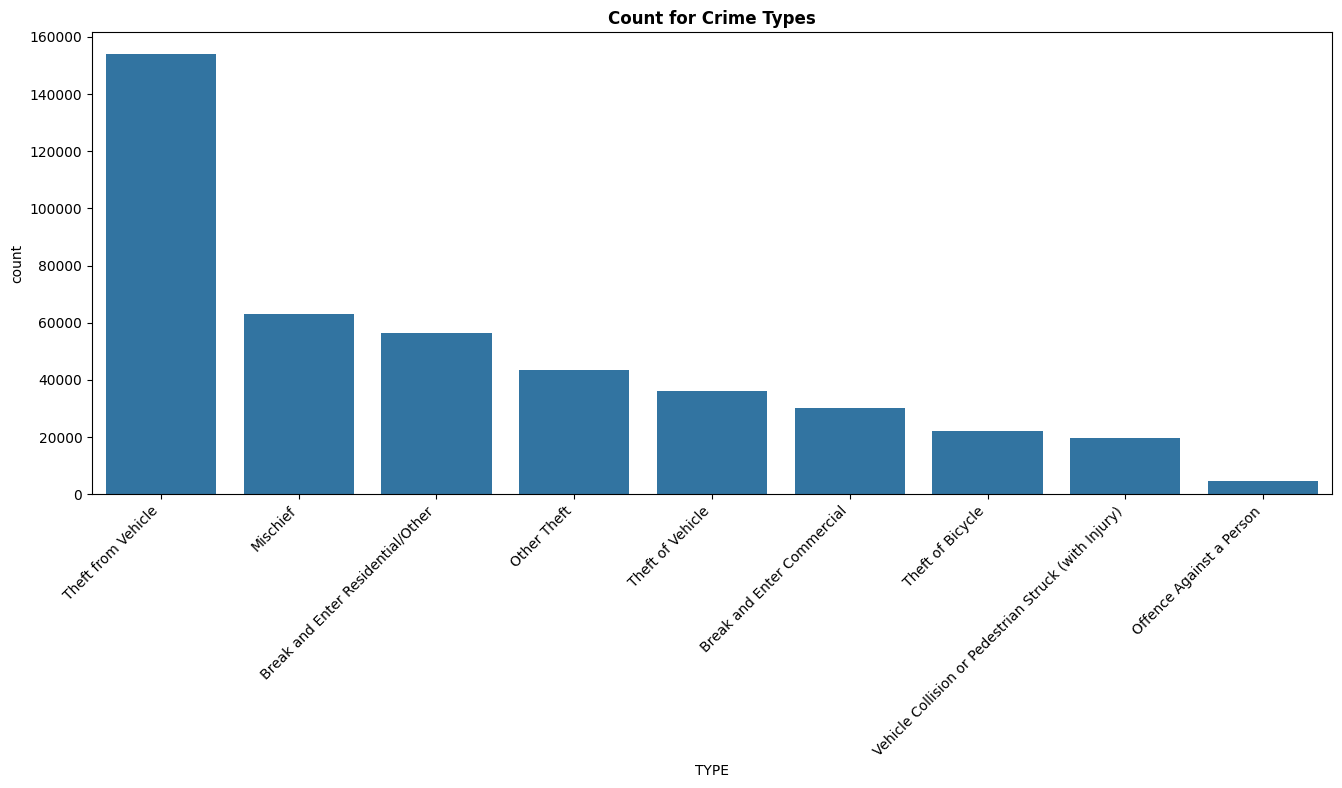

In [ ]:
##code for countplot
plt.figure(figsize=(16,6))
sns.barplot(x='TYPE',y='count',data=cp)
plt.title("Count for Crime Types",weight='bold')
plt.xticks(rotation=45,ha='right')
plt.show()

##### 1. Why did you pick the specific chart?

**Barplot to visualise the Count of each Crime Type and to identify the top 5 crime types.**

##### 2. What is/are the insight(s) found from the chart?

1. **Theft from a vehicle** is the most common crime in US. Mischief/Vandelism of property is the second-most frequent crime.
2. **Property crimes and vehicle related** crimes Dominte the dataset:-

    *   Theft from vehicle
    *   Theft of vehicle, Bicycle
    *   Other theft.
    *   Break and Enter Residential/Burglary

3. Least frequent crimes are **Vehicle collision/Accidents and Offence against a Person.**

#### Chart - 2 Bar plot II

In [ ]:
bp = data['NEIGHBOURHOOD'].value_counts().reset_index()

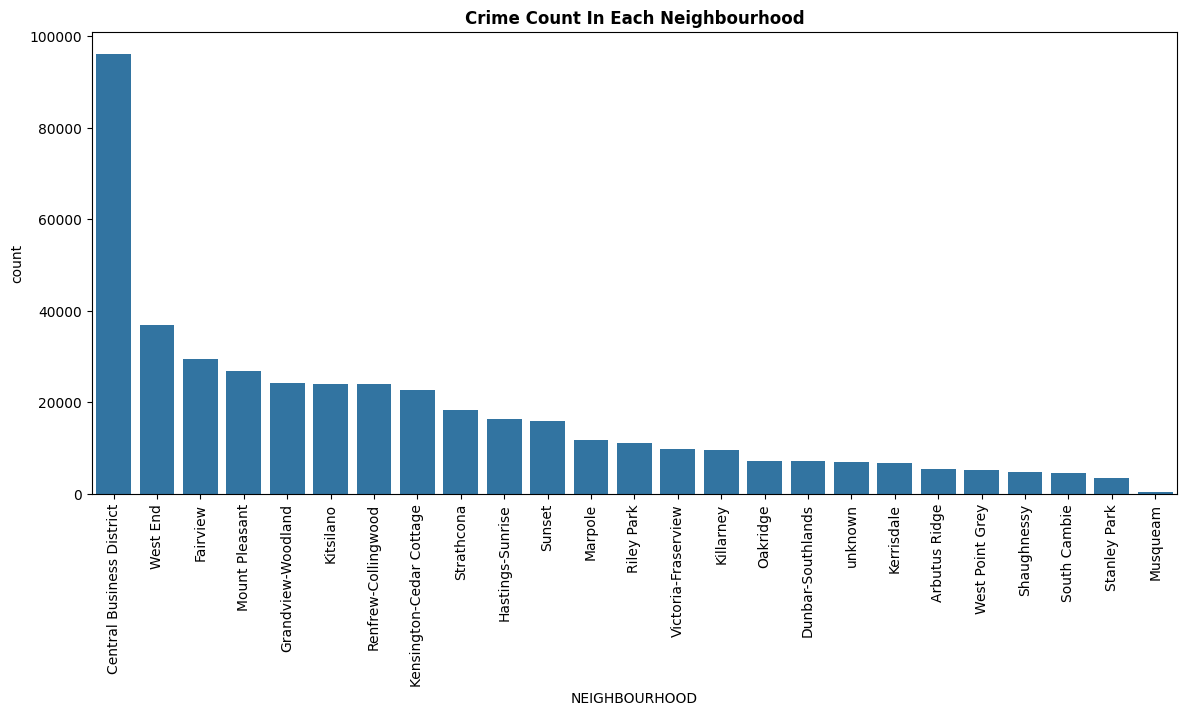

In [ ]:
# Chart - 2 visualization code
plt.figure(figsize=(14,6))
sns.barplot(x=bp['NEIGHBOURHOOD'],y=bp['count'])
plt.title("Crime Count In Each Neighbourhood",weight='bold')
plt.xticks(rotation=90,ha='center')
plt.show()

##### 1. Why did you pick the specific chart?

**Bar Plot to visualise the crime count in each neighbourhood**

##### 2. What is/are the insight(s) found from the chart?

1. The **Central Business District** reports the highest number of crimes by a margin, indicating it is the **primary FBI crime hotspot**.
2. High-Crime neighbourhoods like **Westside, Fairview, Mount Pleasant, and Grandview-Woodland** should be prioritised for targeted law enforcement and Surveillance.
3. Areas like **Musqueam and Stanley Park report minimal FBI crime activity**, whereas urban and commercial hotspots are experiencing significantly higher crime rates (high-frequency neighbourhoods). These neighbourhoods require better resource allocation and optimised patrol deployment.

#### Chart - 3 Countplot

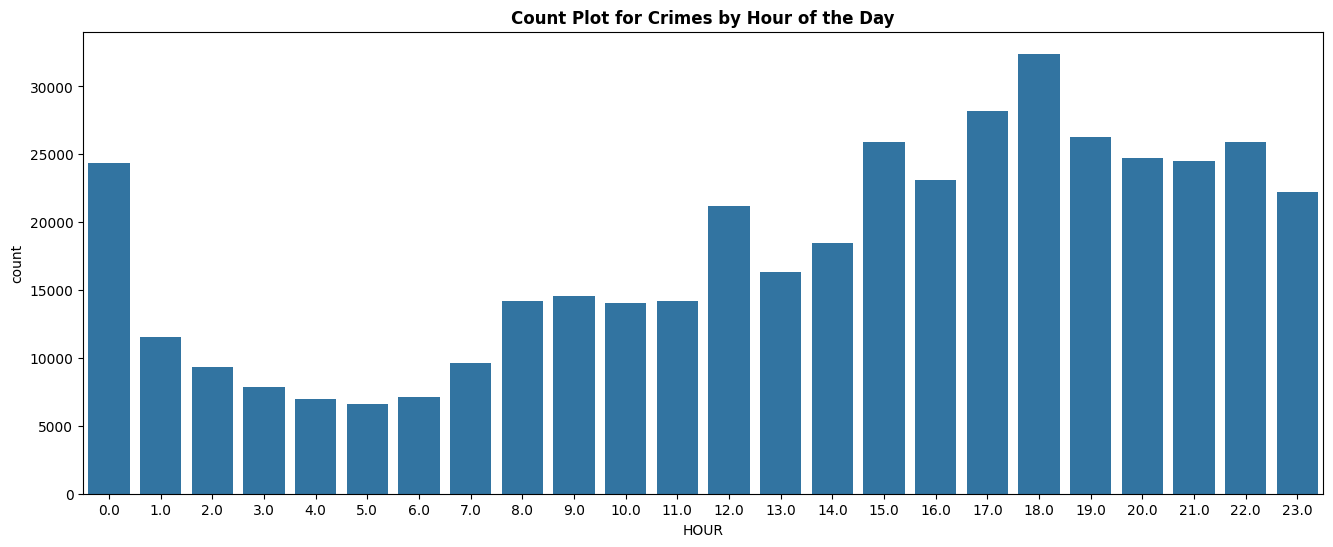

In [ ]:
# Chart - 3 visualization code
plt.figure(figsize=(16,6))
sns.countplot(x='HOUR',data=data)
plt.title('Count Plot for Crimes by Hour of the Day',weight='bold')
plt.show()

##### 1. Why did you pick the specific chart?

**Countplot to identify the Crimes per Hour of the day**

##### 2. What is/are the insight(s) found from the chart?

1. FBI-reported crimes are **lowest during early mornings 3 AM to 6 AM**.
2. The **highest number** of crimes is reported during evening hours, with a peak at **6 PM**. These crime levels **remain high till 11 PM**. This suggests that FBI Property Crimes are more common **during the periods of high public and Vehicle activity.**
3. **Law enforcement patrols** should be prioritised during **late afternoons and Evenings till Midnight** to maximise crime prevention at high public/vehicle activity places.

### BIVARIATE ANALYSIS

#### Chart - 4 Bar plot 1

In [ ]:
##top 10 neighbourhoods wrt crime cout
nc = data['NEIGHBOURHOOD'].value_counts().reset_index().head(10)

In [ ]:
##getting neighbourhood and type
nc1 = data[data['NEIGHBOURHOOD'].isin(nc['NEIGHBOURHOOD'].values)]
nc2 = nc1.groupby(['NEIGHBOURHOOD','TYPE']).size().reset_index()
nc2.rename(columns={0:'count'},inplace=True)


In [ ]:
###top crime types in eachneighbourhood
nc3 = nc2.sort_values(['NEIGHBOURHOOD','count'],ascending=[True,False]).groupby('NEIGHBOURHOOD').head(5)

In [ ]:
# Convert to wide format
pivot_df = (

    nc3.pivot(
        index='NEIGHBOURHOOD',
        columns='TYPE',
        values='count'
    )
    .fillna(0)
)


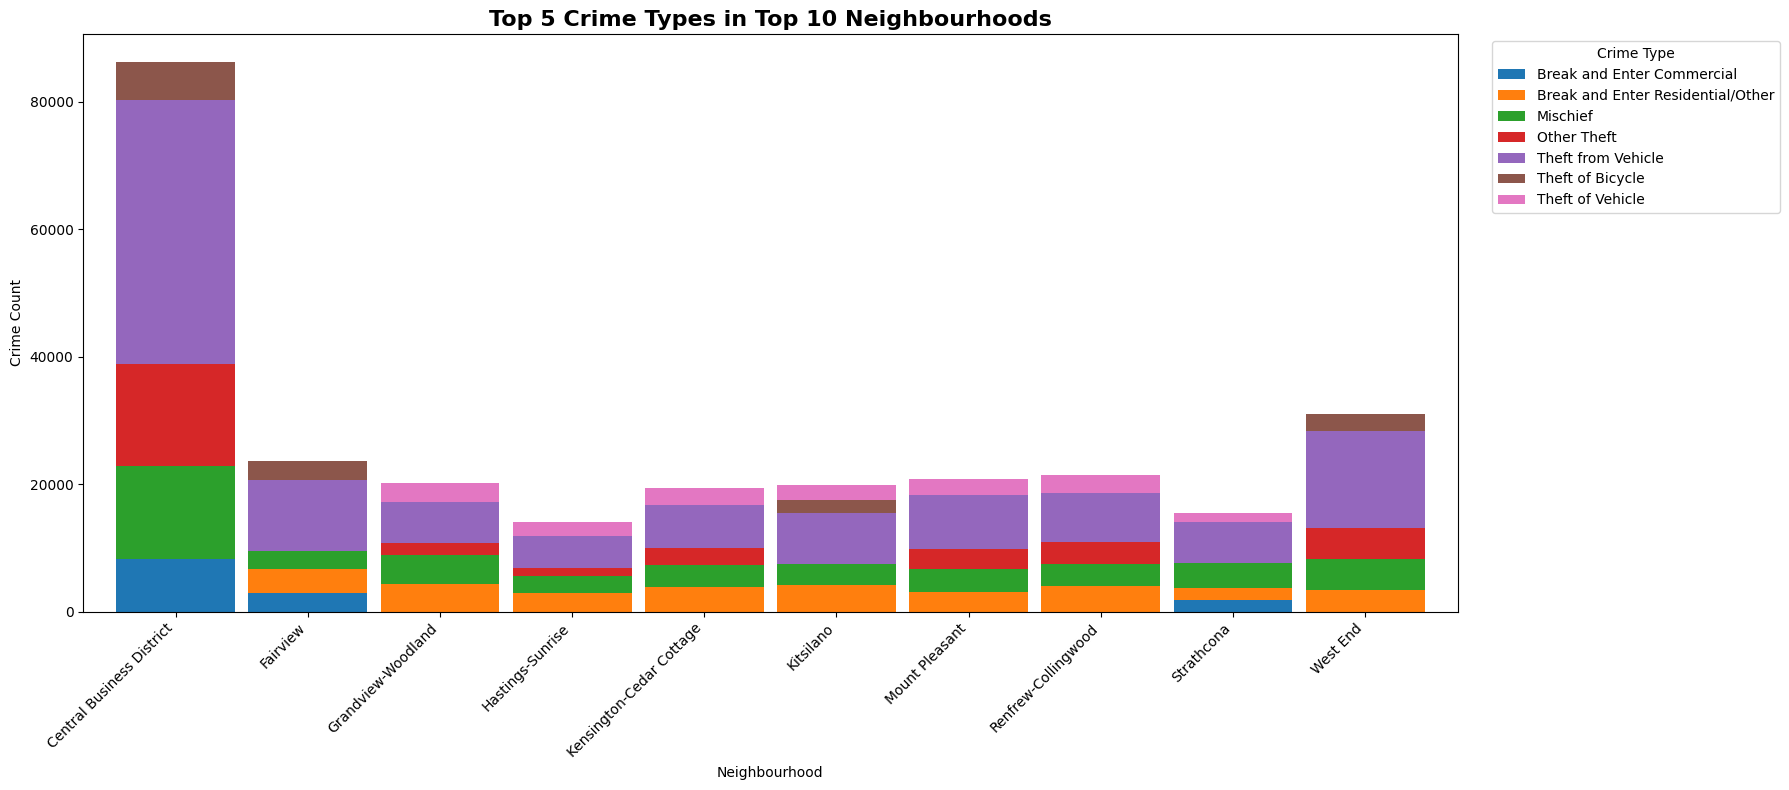

In [ ]:
# Plot stacked bar chart
ax = pivot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(18, 8),
    width=0.9
)

# Formatting
ax.set_title('Top 5 Crime Types in Top 10 Neighbourhoods', fontsize=16, weight='bold')
ax.set_xlabel('Neighbourhood')
ax.set_ylabel('Crime Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Crime Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

1. **Theft from a vehicle** is the most common crime and has the largest count **across all Neighbourhoods**.
2. Burglary, Other thefts and mischief appear prominently in most neighbourhoods.
3. **Theft of Bicycle only reported in urban areas such as CBD, Fairview, Westend and Kitsilano.**

#### Chart - 5 Barplot 2

In [ ]:
##top 10 HUNDRED blokcs wrt crime count
nc = data['HUNDRED_BLOCK'].value_counts().reset_index().head(10)

In [ ]:
##getting blocks and type
nc1 = data[data['HUNDRED_BLOCK'].isin(nc['HUNDRED_BLOCK'].values)]
nc2 = nc1.groupby(['HUNDRED_BLOCK','TYPE']).size().reset_index()
nc2.rename(columns={0:'count'},inplace=True)

In [ ]:
nc3 = nc2.sort_values(['HUNDRED_BLOCK','count'],ascending=[True,False]).groupby('HUNDRED_BLOCK').head(5)

In [ ]:
# Convert to wide format
pivot_df = (

    nc3.pivot(
        index='HUNDRED_BLOCK',
        columns='TYPE',
        values='count'
    )
    .fillna(0)
)

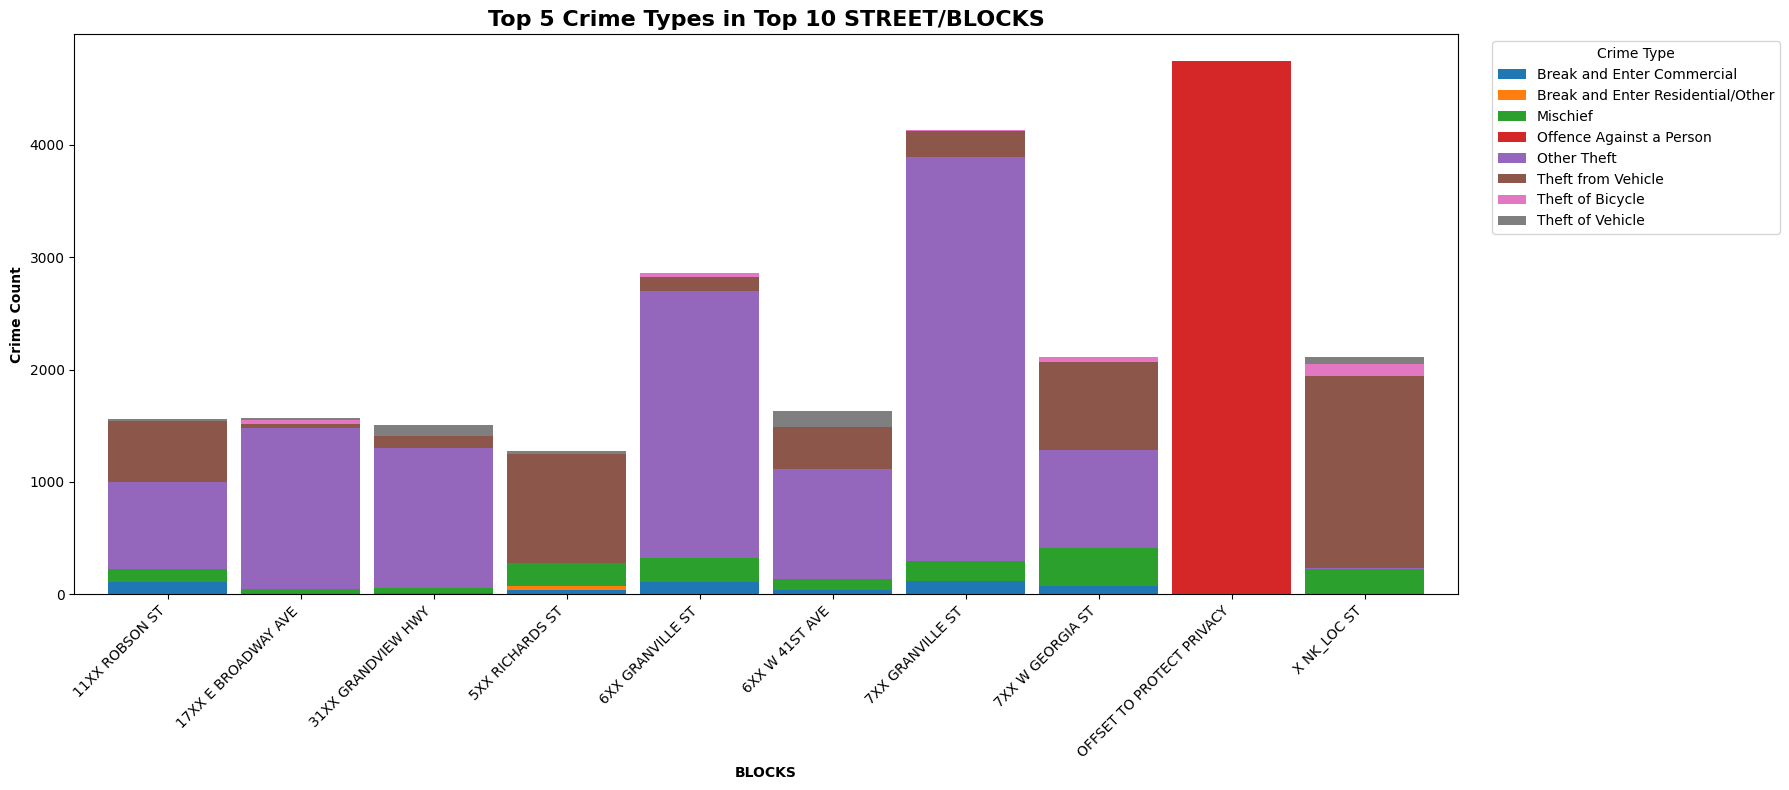

In [ ]:
# Plot stacked bar chart
ax = pivot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(18, 8),
    width=0.9
)

# Formatting
ax.set_title('Top 5 Crime Types in Top 10 STREET/BLOCKS', fontsize=16, weight='bold')
ax.set_xlabel('BLOCKS',weight='bold')
ax.set_ylabel('Crime Count',weight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Crime Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

**Stacked Bar chart to visualize top5 crime types in top10 famous Streets/Blocks**

##### 2. What is/are the insight(s) found from the chart?

1. Blocks named **OFFSET TO PROTECT PRIVACY** are overwhelminly composed of **OFFENCE AGAINST A PERSON incidents (above 4000)**.
2. A couple of **Blocks in GRANVILLE ST** appear among high-crime locations; these blocks can be considered as the **most concentrated crime corridors**.
3. **Other thefts dominate most street blocks**. **Theft from vehicle** is concentrated in blocks such as **Richards ST, X NK_LOC ST, W GEORGIA ST, and ROBSON ST**. **Burglary is the least reported crime.**

### TIMESERIES ANALYSIS

#### CHAT 6:- Yearly trend in crime rate

In [ ]:
#yearly trend
year_df = data.groupby('YEAR').size().reset_index(name='count')

In [ ]:
year_df

,YEAR,count
0,1999,46742
1,2000,45793
2,2001,41200
3,2002,38298
4,2003,33602
5,2004,31519
6,2005,28620
7,2006,26302
8,2007,25042
9,2008,25774


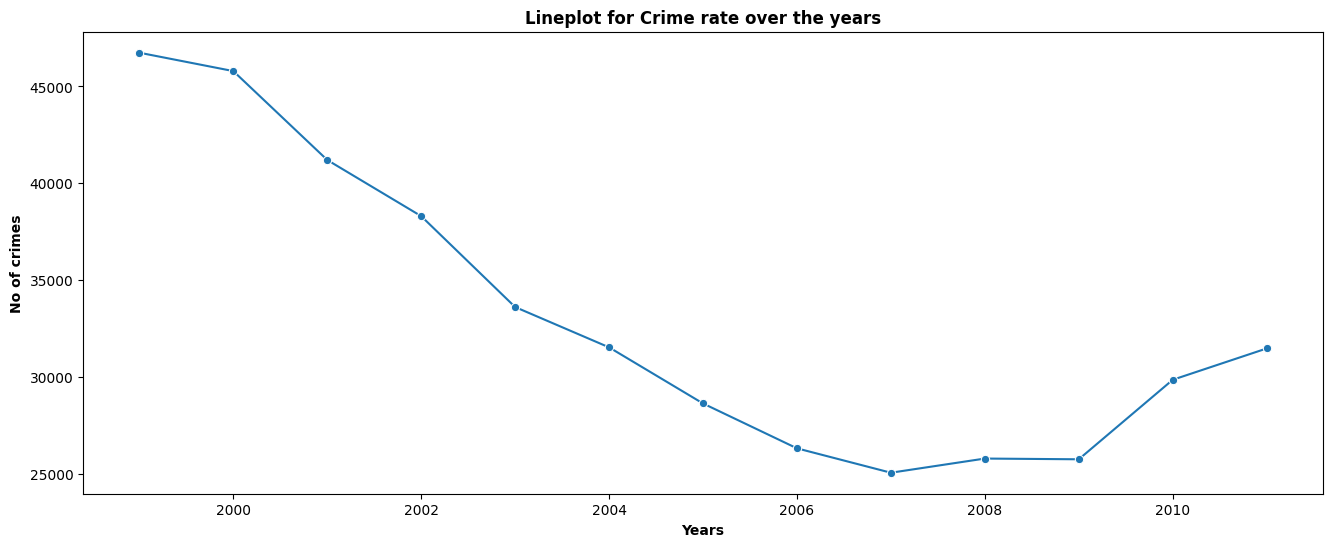

In [ ]:
plt.figure(figsize=(16,6))
sns.lineplot(x='YEAR',y='count',data=year_df,marker='o')
plt.title("Lineplot for Crime rate over the years",weight='bold')
plt.xlabel("Years",weight='bold')
plt.ylabel('No of crimes',weight='bold')
plt.show()

##### 1. Why did you pick the specific chart?

**LINE PLOT for visualising yearly trends in Crime rate**

##### 2. What is/are the insight(s) found from the chart?

1. **Steady decline in FBI-recorded crimes from 1998 to 2008**, indicating improved crime control over this decade.
2. The **highest crime** count was observed in **1990s and early 2000s**. After that, there is a steady decline in the crime rate till 2009.
3. **Lowest crime rate** in the years **2007-2009**.
4. **After 2010**, there was a **moderate increase in the crime rate**. Despite the hikes after 2010, the crime rate is **below the peak** seen during the 1990s.
5. The overall trend indicates a **long-term reduction in FBI-reported crimes**, with **short-term fluctuations** and a slight recovery in later years. the

#### Chart - 7 Monthly Trend

In [ ]:
monthly = data.groupby('MONTH').size().reset_index(name='count')

In [ ]:
monthly

,MONTH,count
0,1,35487
1,2,31871
2,3,35377
3,4,34610
4,5,36461
5,6,36637
6,7,36953
7,8,38436
8,9,36950
9,10,37616


In [ ]:
monthly['MONTH'] = monthly['MONTH'].map({1.0:'Jan',2.0:'Feb',3.0:'Mar',4.0:'Apr',5.0:'May',6.0:'Jun',7.0:'Jul',8.0:'Aug',9.0:'Sep',10.0:'Oct',11.0:'Nov',12.0:'Dec'})

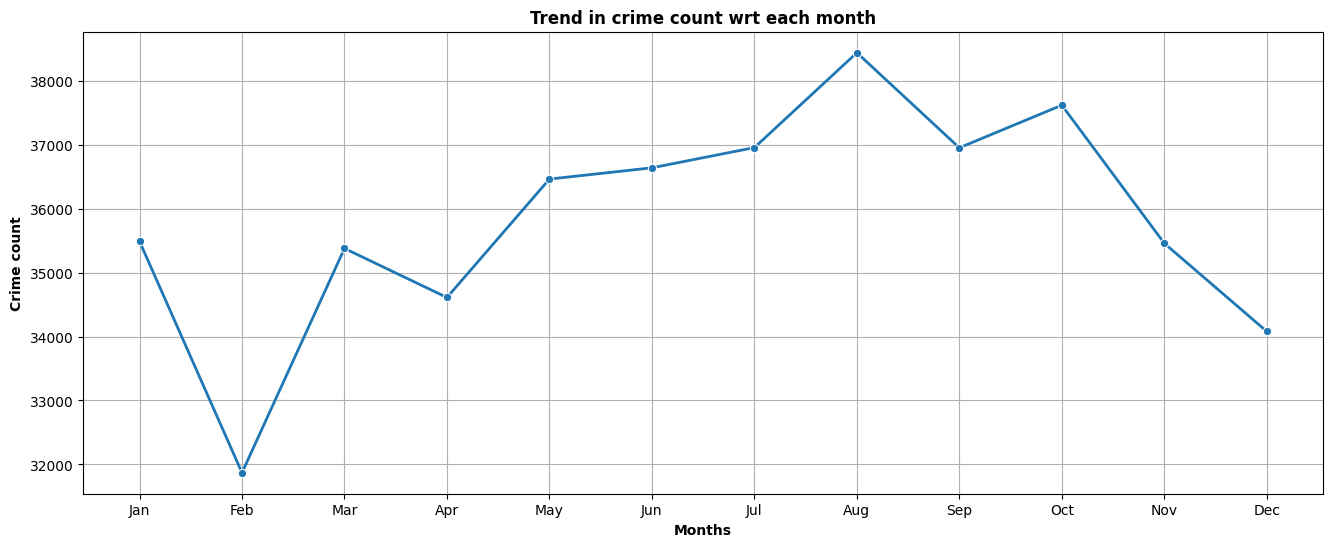

In [ ]:
plt.figure(figsize=(16,6))
sns.lineplot(x='MONTH',y='count',data=monthly,linewidth=2,marker='o')
plt.title("Trend in crime count wrt each month",weight='bold')
plt.xlabel('Months',weight='bold')
plt.ylabel("Crime count",weight='bold')
plt.grid(visible=True)
plt.show()

##### 1. Why did you pick the specific chart?

**LINE PLOT for visualising Monthly trends in Crime rate**

##### 2. What is/are the insight(s) found from the chart?

1. FBI-reported crime are **least during February**.
2. Crime rate is higher in the months of July, August, September, and October. **August shows the highest number of crimes.**
3. Reported cirmes **decline in November and December**.

#### Chart - 8 Seasonal decompose

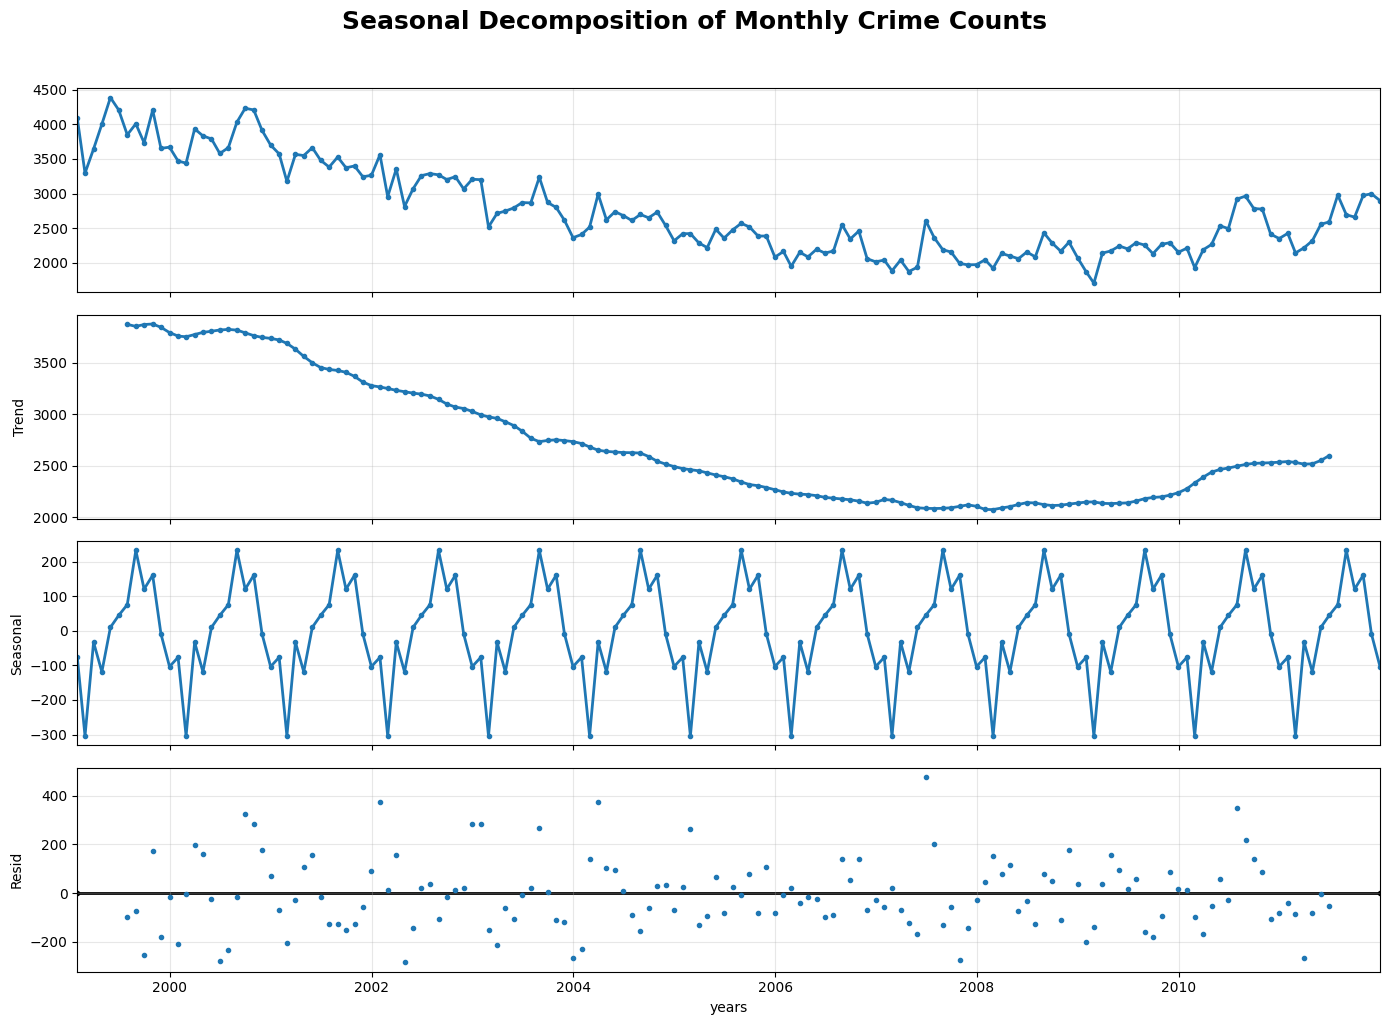

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

##data for seasonal decompose
df= (
    data.set_index('Date')
      .resample('ME')
      .size()
)

##seasonal decompose
sd = seasonal_decompose(df,model='additive',period=12)

##plotting graphs
fig = sd.plot()
fig.set_size_inches(14, 10)

for ax in fig.axes:
    for line in ax.get_lines():
        line.set_linewidth(2)      # Increase line thickness
        line.set_marker('o')       # Add circular markers
        line.set_markersize(3)     # Marker size

    ax.grid(True, alpha=0.3)

# Add overall title
fig.suptitle(
    'Seasonal Decomposition of Monthly Crime Counts',
    fontsize=18,
    fontweight='bold',
    y=1.02
)

plt.xlabel("years")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

**Seasonal decompose to identify seasonality, trends and residuals in the FBI crime count.**

##### 2. What is/are the insight(s) found from the chart?

1. The **long-term tren**d shows a steady decline in the FBI-reported crimes over the years.
2. A **clear and repeating 12-month/annual seasonal pattern** is present. Higher crime during August to October and lower during the winter.
3. **Residuals are centered around zero** and within moderate range, suggesting limited unexpected noise. A few large positive and negative results around 2007 suggests unusual crime spikes and drops.
4. The series is **NON-STATIONARY** due to downward trend and seasonality. Therefore, the data is well suited for the **seasonal forecasting models** such as:-**SARIMA and Holt Winters Exponential Smoothing**.

#### Chart - 9 Correlation Heatmap

In [ ]:
##label encoding crime type with its frequency
type_freq = data['TYPE'].value_counts()
data1=data.copy()

data1['type_freq'] = data1['TYPE'].map(type_freq)

In [ ]:
data1.head()

,TYPE,HUNDRED_BLOCK,NEIGHBOURHOOD,X,Y,Latitude,Longitude,HOUR,MINUTE,YEAR,MONTH,DAY,Date,type_freq
0,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,16.0,15.0,1999,5,12,1999-05-12,43590
1,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,15.0,20.0,1999,5,7,1999-05-07,43590
2,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,16.0,40.0,1999,4,23,1999-04-23,43590
3,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,11.0,15.0,1999,4,20,1999-04-20,43590
4,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,17.0,45.0,1999,4,12,1999-04-12,43590


In [ ]:
###columns for heatmap
cols=['type_freq','DAY','HOUR','MONTH','YEAR']


In [ ]:
##heatmap data
cor = data1[cols].corr()

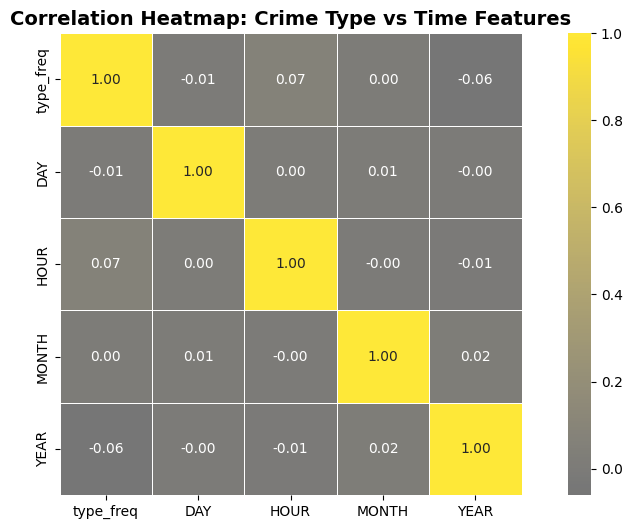

In [ ]:
# Chart - 8 visualization code
plt.figure(figsize=(12,6))
sns.heatmap(
    cor,
    annot=True,
    fmt='.2f',
    cmap='cividis',
    center=0,
    linewidths=0.5,
    square=True
)

plt.title(
    'Correlation Heatmap: Crime Type vs Time Features',
    fontsize=14,
    fontweight='bold'
)
plt.show()

##### 1. Why did you pick the specific chart?

**Correlation heatmap to check the relationship between crime type and time features**

##### 2. What is/are the insight(s) found from the chart?

**All correlations are very close to zero, indicating no linear relationships between crime frequency and time-based features.**

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

1. **Time series data contains trends and seasonality.**
2. **Crime counts differ by the Neighbourhood.**
3. **Crime count differs by the Hour of the day.**

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

1. **Ho**:- The series is has a unit root/not stationary
2. **Ha**:- The series is stationary

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
from statsmodels.tsa.stattools import adfuller
result = adfuller(df)

print("ADF statistic: ",result[0])
print("p_value: ",result[1])

ADF statistic:  -2.40601547896735
p_value:  0.14004577751289143


##### Which statistical test have you done to obtain P-Value?

**ADFULLER TEST:** It is test used to determine weather the Timeseries dataset is stationary or not. It checks weather the dataset has constant mean, variance, and constant autocorrelation structure over time.

The p-value of the adfuller test is significantly greater than 0.05. Therefore, we donot have enoguh evidence to reject the null hypothesis and we can conclude that the **Timeseries dataset is non-stationary**.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

1. **Ho**:-Crime count is independent of neighbourhood.
2. **Ha**:- Crime count is dependent on neighbourhood.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import chi2_contingency
table = pd.crosstab(data['NEIGHBOURHOOD'],data['TYPE'])  ###pivot table

In [ ]:
##chi1 square test
chi,p,dof,expected = chi2_contingency(table)

print(f"chi square statitic: {chi:2f}")
print(f"p value: {p:.6f}")

chi square statitic: 346825.349864
p value: 0.000000


##### Which statistical test have you done to obtain P-Value?

**CHI-square goodness of fit test:-** This test is used to determine whether the observed frequency of categories differs significantly from the expected distribution. The Chi2 test is ideally suited for count-based categorical data and doesn't assume normality of the data distribution. Chi2 compares observed counts with expected counts, and the chi2 value quantifies the difference between them.

**The p-value is significanlty lower than 0.05. Therfore we have enough evidence to reject the null hypothesis and we can conclude that Crime count varies with the neighbourhood.**

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

1. **Ho**: Crime occurrences are evenly distributed across hours.
2. **Ha** Crime occurrences vary by hour.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import chisquare
hour_counts = data['HOUR'].value_counts().sort_index()


In [ ]:
hour_counts.head()

,count
HOUR,
0.0,24333
1.0,11563
2.0,9358
3.0,7863
4.0,6997


In [ ]:
chi,p = chisquare(hour_counts)
print(f"chi2 test statistic: {chi:.3f}")
print(f"p-value: {p:.6f}")

chi2 test statistic: 78472.899
p-value: 0.000000


##### Which statistical test have you done to obtain P-Value?

**CHI2 test:- P-value is less than 0.05. Reject the null hypothesis. Crime count varies by the Hour of the day**

## ***6. Feature Engineering & Data Pre-processing***

#### Standardizing Text Columns

In [ ]:
##remving extra spaces if any
text_cols = ['TYPE','NEIGHBOURHOOD','HUNDRED_BLOCK']
for cols in text_cols:
  data[cols] = data[cols].str.strip()


### **Data preprocessing and Feature Enginering for Stage1**

#### 1. Data Aggregation

In [ ]:
df1 = data.groupby(['YEAR','MONTH']).size().reset_index(name="Total_crime_count")  ## crime count for each month every year

In [ ]:
df1.head()

,YEAR,MONTH,Total_crime_count
0,1999,1,4089
1,1999,2,3296
2,1999,3,3644
3,1999,4,4002
4,1999,5,4386


#### 2. Date column creation

In [ ]:
df1['DATE'] = pd.to_datetime(dict(year=df1['YEAR'],month=df1['MONTH'],day=1))

In [ ]:
df1.head()

,YEAR,MONTH,Total_crime_count,DATE
0,1999,1,4089,1999-01-01
1,1999,2,3296,1999-02-01
2,1999,3,3644,1999-03-01
3,1999,4,4002,1999-04-01
4,1999,5,4386,1999-05-01


#### 3. Feature Engineering

In [ ]:
##lag1 capture previous month crime count
df1['lag_1'] = df1['Total_crime_count'].shift(1)

In [ ]:
df1.head()

,YEAR,MONTH,Total_crime_count,DATE,lag_1
0,1999,1,4089,1999-01-01,NaN
1,1999,2,3296,1999-02-01,4089.0
2,1999,3,3644,1999-03-01,3296.0
3,1999,4,4002,1999-04-01,3644.0
4,1999,5,4386,1999-05-01,4002.0


In [ ]:
##lag 12 capture crime count smae month previous year
df1['lag_12'] = df1['Total_crime_count'].shift(12)

In [ ]:
df1.head()

,YEAR,MONTH,Total_crime_count,DATE,lag_1,lag_12
0,1999,1,4089,1999-01-01,NaN,NaN
1,1999,2,3296,1999-02-01,4089.0,NaN
2,1999,3,3644,1999-03-01,3296.0,NaN
3,1999,4,4002,1999-04-01,3644.0,NaN
4,1999,5,4386,1999-05-01,4002.0,NaN


In [ ]:
## rolling mean for every 3months
df1['rolling_3mean'] = df1['Total_crime_count'].shift(1).rolling(3).mean()

In [ ]:
df1.head()

,YEAR,MONTH,Total_crime_count,DATE,lag_1,lag_12,rolling_3mean
0,1999,1,4089,1999-01-01,NaN,NaN,NaN
1,1999,2,3296,1999-02-01,4089.0,NaN,NaN
2,1999,3,3644,1999-03-01,3296.0,NaN,NaN
3,1999,4,4002,1999-04-01,3644.0,NaN,3676.333333
4,1999,5,4386,1999-05-01,4002.0,NaN,3647.333333


In [ ]:
###rolling standing deviation every 3months
df1['rolling_3std'] = df1['Total_crime_count'].shift(1).rolling(3).std()

In [ ]:
df1.head()

,YEAR,MONTH,Total_crime_count,DATE,lag_1,lag_12,rolling_3mean,rolling_3std
0,1999,1,4089,1999-01-01,NaN,NaN,NaN,NaN
1,1999,2,3296,1999-02-01,4089.0,NaN,NaN,NaN
2,1999,3,3644,1999-03-01,3296.0,NaN,NaN,NaN
3,1999,4,4002,1999-04-01,3644.0,NaN,3676.333333,397.487526
4,1999,5,4386,1999-05-01,4002.0,NaN,3647.333333,353.011803


In [ ]:
##cyclic encoding to prevent the seasonal continuity of months(december and january)
df1['month_sin'] = np.sin(2*np.pi*df1['MONTH']/12)
df1['month_cos'] = np.cos(2*np.pi*df1['MONTH']/12)

In [ ]:
df1.head()

,YEAR,MONTH,Total_crime_count,DATE,lag_1,lag_12,rolling_3mean,rolling_3std,month_sin,month_cos
0,1999,1,4089,1999-01-01,NaN,NaN,NaN,NaN,0.500000,8.660254e-01
1,1999,2,3296,1999-02-01,4089.0,NaN,NaN,NaN,0.866025,5.000000e-01
2,1999,3,3644,1999-03-01,3296.0,NaN,NaN,NaN,1.000000,6.123234e-17
3,1999,4,4002,1999-04-01,3644.0,NaN,3676.333333,397.487526,0.866025,-5.000000e-01
4,1999,5,4386,1999-05-01,4002.0,NaN,3647.333333,353.011803,0.500000,-8.660254e-01


In [ ]:
##creating a time index
df1['time_index'] = np.arange(len(df1))

In [ ]:
df1.head()

,YEAR,MONTH,Total_crime_count,DATE,lag_1,lag_12,rolling_3mean,rolling_3std,month_sin,month_cos,time_index
0,1999,1,4089,1999-01-01,NaN,NaN,NaN,NaN,0.500000,8.660254e-01,0
1,1999,2,3296,1999-02-01,4089.0,NaN,NaN,NaN,0.866025,5.000000e-01,1
2,1999,3,3644,1999-03-01,3296.0,NaN,NaN,NaN,1.000000,6.123234e-17,2
3,1999,4,4002,1999-04-01,3644.0,NaN,3676.333333,397.487526,0.866025,-5.000000e-01,3
4,1999,5,4386,1999-05-01,4002.0,NaN,3647.333333,353.011803,0.500000,-8.660254e-01,4


In [ ]:
##adding quarters i.e to which quarter the month belongs to
df1['quarter'] = ((df1['MONTH']-1)//3) + 1

In [ ]:
df1.head()

,YEAR,MONTH,Total_crime_count,DATE,lag_1,lag_12,rolling_3mean,rolling_3std,month_sin,month_cos,time_index,quarter
0,1999,1,4089,1999-01-01,NaN,NaN,NaN,NaN,0.500000,8.660254e-01,0,1
1,1999,2,3296,1999-02-01,4089.0,NaN,NaN,NaN,0.866025,5.000000e-01,1,1
2,1999,3,3644,1999-03-01,3296.0,NaN,NaN,NaN,1.000000,6.123234e-17,2,1
3,1999,4,4002,1999-04-01,3644.0,NaN,3676.333333,397.487526,0.866025,-5.000000e-01,3,2
4,1999,5,4386,1999-05-01,4002.0,NaN,3647.333333,353.011803,0.500000,-8.660254e-01,4,2


In [ ]:
df1['MONTH'] = df1['MONTH'].astype(int)

In [ ]:
df1['quarter'] = df1['quarter'].astype(int)

In [ ]:
df1 = df1.replace([np.inf, -np.inf], np.nan)

In [ ]:
##dropping null values
df1.dropna(inplace=True)

#### 4. Data Splitting

In [ ]:
x= df1.drop(['Total_crime_count',],axis=1)
y=df1[['DATE','Total_crime_count']]

In [ ]:
x.set_index('DATE',inplace=True)
y.set_index('DATE',inplace=True)

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely
train_size = int(len(df1)*0.8)
test_size = int(len(df1)*0.2)

x_train =x.iloc[:train_size]
y_train = y.iloc[:train_size]
x_test,y_test = x.iloc[train_size:],y.iloc[train_size:]

In [ ]:
##training shape
x_train.shape, y_train.shape

((115, 10), (115, 1))

In [ ]:
y_train.head()

,Total_crime_count
DATE,
2000-01-01,3470
2000-02-01,3440
2000-03-01,3935
2000-04-01,3833
2000-05-01,3789


In [ ]:
##testing shape
x_test.shape, y_test.shape

((29, 10), (29, 1))

## ***7. STAGE 1:- ML Model Implementation For Monthly Crime Count Forecasting***

### ML Model - 1 SARIMAX

#### Training and Testing

In [ ]:
train_df = data.set_index('Date').resample('ME').size()
train_df.name='count'

In [ ]:
train_df.head()

,count
Date,
1999-01-31,4089
1999-02-28,3296
1999-03-31,3644
1999-04-30,4002
1999-05-31,4386


In [ ]:
n = int(len(train_df)*0.90)
train = train_df.iloc[:n]
test = train_df.iloc[n:]

In [ ]:
# ML Model - 1 Implementation
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

warnings.filterwarnings('ignore')

srm = SARIMAX(train,order=(2,1,2),seasonal_order=(2,1,2,12))

# Fit the Algorithm
srm1 = srm.fit(disp=False)
print(srm1.summary)


<bound method SARIMAXResults.summary of <statsmodels.tsa.statespace.sarimax.SARIMAXResults object at 0x78ce975d8800>>


In [ ]:
# Predict on the model
pred = srm1.forecast(steps=len(test))

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**SARIMAX(SEASONAL AUTOREGRESSIVE INTEGRATED MOVING AVERAGE WTH EXOGENOUS REGESSOR)** is an advanced statistical model used for time series forecasting. It extends ARIMA by modelling with trends, seasonal patterns and external influencing factors to prediction accuracy. It is widely used for economics, sales prediction and wheather forecasting.

**Parameters:**
1. P --> AutoRegressive order for seasonal component.
2. D --> Order of difference for seasonal component.
3. Q --> Moving average order for seasonal component.
4. m --> The number of time steps for a single seasonal cycle.


In [ ]:
# Visualizing evaluation Metric Score chart
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
mae = mean_absolute_error(test,pred)
rmse = root_mean_squared_error(test,pred)
print('Mean absolute error: ',mae)
print('Root mean squared error: ',rmse)

Mean absolute error:  168.44827891818767
Root mean squared error:  237.1239804117545


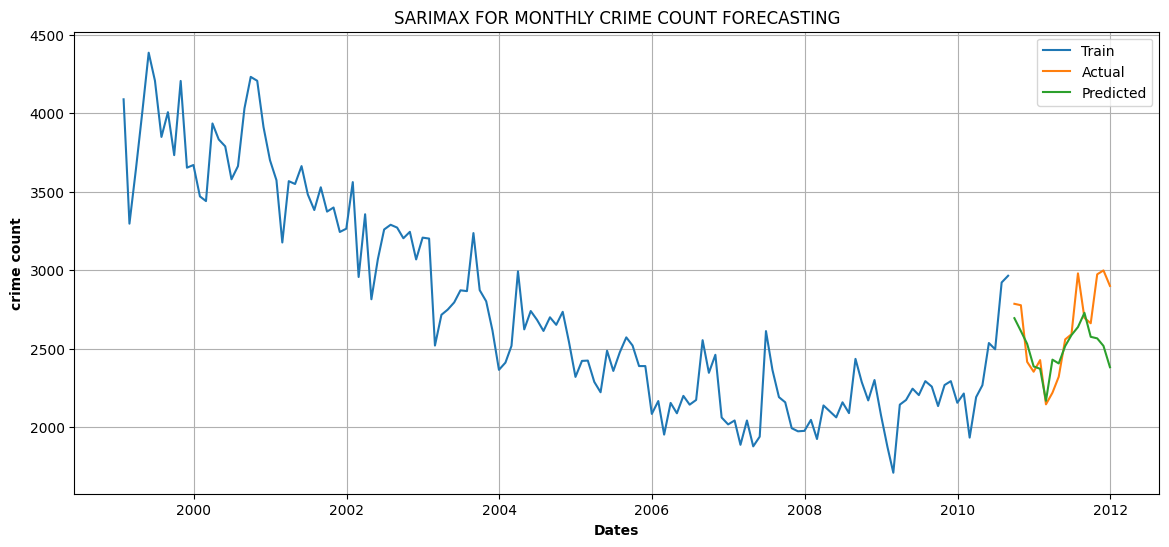

In [ ]:
##actual vs predicted plot
plt.figure(figsize=(14,6))
plt.plot(train.index,train,label='Train')
plt.plot(test.index,test,label='Actual')
plt.plot(test.index,pred,label='Predicted')
plt.title("SARIMAX FOR MONTHLY CRIME COUNT FORECASTING")
plt.xlabel("Dates",weight='bold')
plt.ylabel("crime count",weight='bold')
plt.legend()
plt.grid()
plt.show()


**Mean Absolute error score for SARIMAX is ~168.00 . The model was able to approximately predict the increase in crime count after 2010, i.e model was able capture the seasonal and trend pattern in crime count post 2010.**

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (TIMESERIESSPLIT)
from sklearn.model_selection import TimeSeriesSplit
from itertools import product
tscv = TimeSeriesSplit(n_splits=8)
for train_idx,val_idx in tscv.split(train):
  train1 = train.iloc[train_idx]
  valid = train.iloc[val_idx]

P=Q=range(1,4)
p=q=range(1,4)
d=1
s =12
pq = list(product(p,q))
ses_pq = list(product(P,Q))

D=1
best_mse = float("inf")
best_order=None
best_ses_order = None
for order in pq:
  orders = (order[0],d,order[1])
  for ses_ord in ses_pq:
    ses_order = (ses_ord[0],D,ses_ord[1],s)
    model = SARIMAX(train1,order=orders,seasonal_order=ses_order)
    result = model.fit( disp=False,method='powell',maxiter=200)
    pred = result.forecast(steps=len(valid))
    mse = mean_absolute_error(valid,pred)

    print(f"{mse} for the order = {orders} and seasonal order = {ses_order}")

    if mse<best_mse:
      best_mse = mse
      best_order = orders
      best_ses_order = ses_order


print("*** Parameters for the best model are: \n****")
print("best_order: ",best_order)
print("best mean absolute error: ",best_mse)
print("best seasonal order: ",best_ses_order)

319.7012429382281 for the order = (1, 1, 1) and seasonal order = (1, 1, 1, 12)
312.5696702213908 for the order = (1, 1, 1) and seasonal order = (1, 1, 2, 12)
304.22969772343873 for the order = (1, 1, 1) and seasonal order = (1, 1, 3, 12)
317.6945688222385 for the order = (1, 1, 1) and seasonal order = (2, 1, 1, 12)
311.7023878763824 for the order = (1, 1, 1) and seasonal order = (2, 1, 2, 12)
347.04545631587655 for the order = (1, 1, 1) and seasonal order = (2, 1, 3, 12)
295.04124006341993 for the order = (1, 1, 1) and seasonal order = (3, 1, 1, 12)
310.236693838898 for the order = (1, 1, 1) and seasonal order = (3, 1, 2, 12)
305.5587310739606 for the order = (1, 1, 1) and seasonal order = (3, 1, 3, 12)
304.99147527897765 for the order = (1, 1, 2) and seasonal order = (1, 1, 1, 12)
309.2077895458959 for the order = (1, 1, 2) and seasonal order = (1, 1, 2, 12)
302.79644534070565 for the order = (1, 1, 2) and seasonal order = (1, 1, 3, 12)
304.3320742801169 for the order = (1, 1, 2) and 

##### Which hyperparameter optimization technique have you used and why?

**TIMESERIES-SPLIT is as used as crossvalidation to make 5 splits in traning data and for order and seasonal order tuning for SARIMAX model. The best order and seasonal order for SARIMAX are (3,1,3) and (1,1,3,12) respectively.**

In [ ]:
##reatraing the model on full train data
model = SARIMAX(train,order=(3,1,3),seasonal_order=(1,1,3,12))
result = model.fit(disp=False,method='powell',maxiter=200)

In [ ]:
###prediction on test data
pred1 = result.forecast(steps=len(test))
mse = mean_absolute_error(test,pred1)
print(f"mean absolute error is {mse}")

mean absolute error is 198.84760937237576


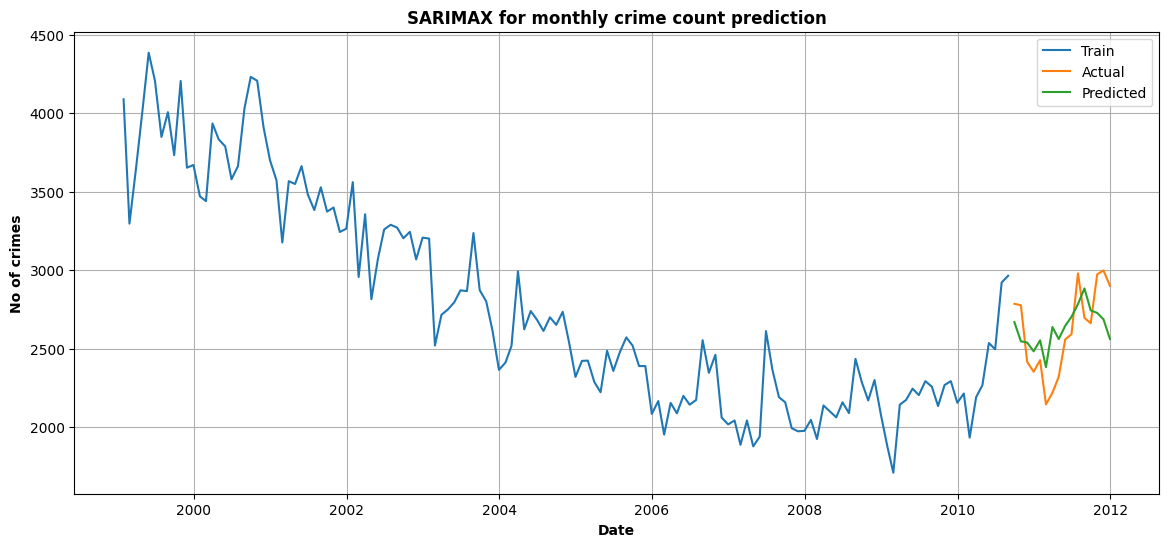

In [ ]:
##plotting actual vs predicted data
plt.figure(figsize=(14,6))
plt.plot(train.index,train,label='Train')
plt.plot(test.index,test,label='Actual')
plt.plot(test.index,pred1,label='Predicted')
plt.title("SARIMAX for monthly crime count prediction",weight='bold')
plt.xlabel("Date",weight='bold')
plt.ylabel('No of crimes',weight='bold')
plt.grid()
plt.legend()
plt.show()


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

**SARIMA wroked well during training, but after cross validation and hyperparameter tuning the error persists and is larger than before (~~199.0), and the model able to approximately predict the increase in crime count post 2010. But it was not as good as the previous model**

### ML Model -2 HOLT WINTERS EXPONENTIAL SMOOTHING

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
model = ExponentialSmoothing(train,trend='add',seasonal='add',seasonal_periods=12,damped_trend=True)
fits = model.fit(optimized=True)

In [ ]:
#prediction
hpred=fits.forecast(steps=len(test))

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

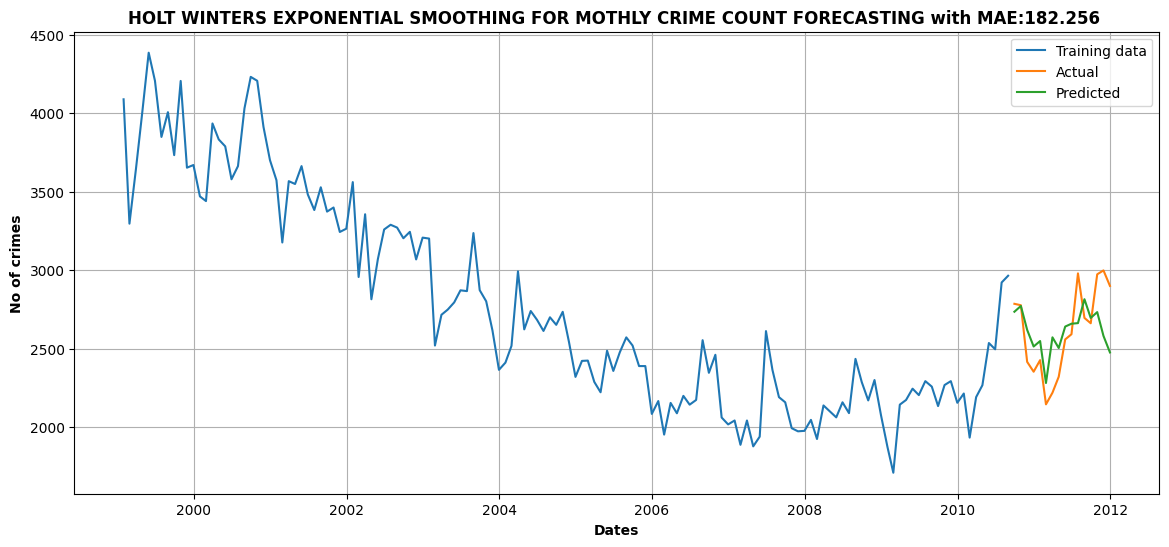

In [ ]:
# Visualizing evaluation Metric Score chart
mae = mean_absolute_error(test,hpred)

plt.figure(figsize=(14,6))
plt.plot(train.index,train,label='Training data')
plt.plot(test.index,test,label='Actual')
plt.plot(test.index,hpred,label='Predicted')
plt.xlabel('Dates',weight='bold')
plt.ylabel('No of crimes',weight='bold')
plt.title(f"HOLT WINTERS EXPONENTIAL SMOOTHING FOR MOTHLY CRIME COUNT FORECASTING with MAE:{mae:.3f} ",weight='bold')
plt.legend()
plt.grid()
plt.show()

**Holt winters exponential smoothing is a classical time series forecasting model that can handle: level, trend, and seasonality.**

**FORECAST = LEVEL + TREND + SEASONALITY.** The model continuously updates these compnents by assigning greater weights to the most recent observations.

1. **LEVEL** :- Current baseline crime count.
2. **Trend** :-  Monthly increase or decrease in crime count.
3. **Seasonality** :- Regular patterns that appear every 12 months.

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
tscv = TimeSeriesSplit(n_splits=5)

##parameters
t=['add','mul']
s=['add','mul']
sp=12
dp='True'

best_mae=float("inf")
best_t=None
best_s=None

##splitting
for train_idx,val_idx in tscv.split(train):
  train1 = train.iloc[train_idx]
  valid = train.iloc[val_idx]


# Fit the Algorithm
for trend in t:
  for seasonal in s:
    model = ExponentialSmoothing(train1,trend=trend,seasonal=seasonal,seasonal_periods=sp,damped_trend=True)
    fits = model.fit(optimized=True)
    # Predict on the model
    hpred1 = fits.forecast(steps = len(valid))
    mae = mean_absolute_error(valid,hpred1)
    print(f"mean absolute error is {mae} for trend={trend}, seasonal={seasonal}")

    if mae <best_mae:
      best_mae=mae
      best_t=trend
      best_s=seasonal


print("Best parameters for holt winters  model\n")
print("Best mae",best_mae)
print("best trend option ",best_t)
print("best seasonal option ",best_s)



mean absolute error is 319.1130886153918 for trend=add, seasonal=add
mean absolute error is 286.40880583819535 for trend=add, seasonal=mul
mean absolute error is 178.54389928900073 for trend=mul, seasonal=add
mean absolute error is 194.01697310514473 for trend=mul, seasonal=mul
Best parameters for holt winters  model

Best mae 178.54389928900073
best trend option  mul
best seasonal option  add


In [ ]:
##training the model with updated parameters
model = ExponentialSmoothing(train,trend='mul',seasonal='add',seasonal_periods=12,damped_trend=True)
fits = model.fit(optimized=True)

In [ ]:
##prediction
hpred = fits.forecast(steps=len(test))
mae = mean_absolute_error(test,hpred)
print("mean absolute error: ",mae)

mean absolute error:  204.44717505730412


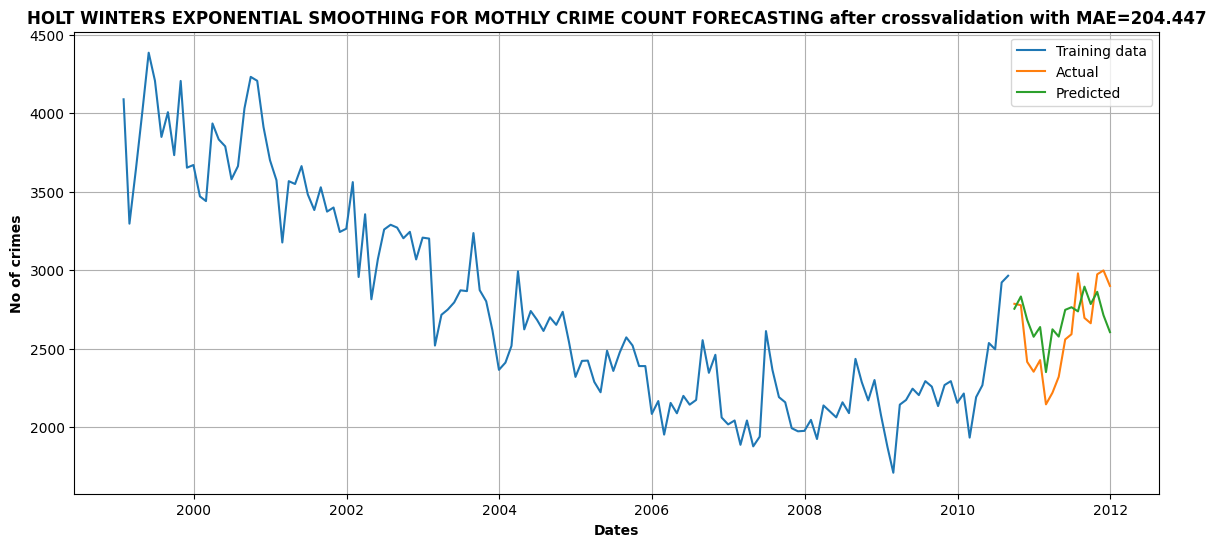

In [ ]:
##chart
plt.figure(figsize=(14,6))
plt.plot(train.index,train,label='Training data')
plt.plot(test.index,test,label='Actual')
plt.plot(test.index,hpred,label='Predicted')
plt.xlabel('Dates',weight='bold')
plt.ylabel('No of crimes',weight='bold')
plt.title(f"HOLT WINTERS EXPONENTIAL SMOOTHING FOR MOTHLY CRIME COUNT FORECASTING after crossvalidation with MAE={mae:.3f}",weight='bold')
plt.legend()
plt.grid()
plt.show()

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

**There is no significant imporvement in the model after crossvalidation. The simple Holt winters model performed well, its error score is ~~184.00 and was able to approximately capture the seasonality and trend patterns in dataset.**

### ML Model - 3 LINEAR, RIDGE, LASSO REGRESSION

In [ ]:
# ML Model - 3 Implementation
from sklearn.linear_model import LinearRegression
# Fit the Algorithm
model = LinearRegression()
model.fit(x_train,y_train)

# Predict on the model
lpred = model.predict(x_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart
mae = mean_absolute_error(y_test,lpred)
print("mean absolute error for linear regression: ",mae)

mean absolute error for linear regression:  239.7495723549287


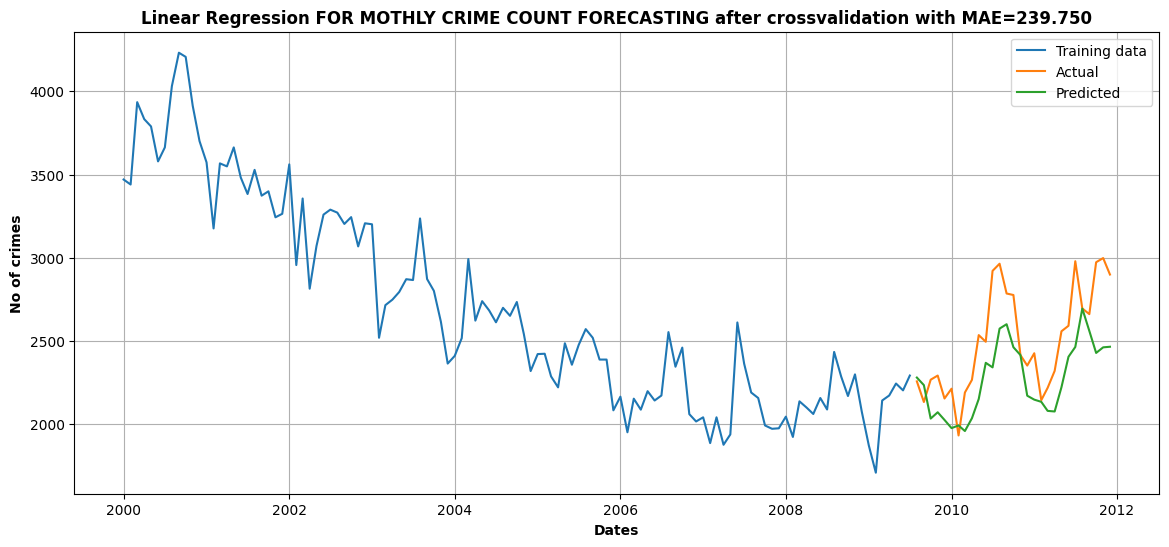

In [ ]:
##chart
import matplotlib.dates as mdates

plt.figure(figsize=(14,6))
plt.plot(y_train.index,y_train,label='Training data')
plt.plot(y_test.index,y_test,label='Actual')
plt.plot(y_test.index,lpred,label='Predicted')
plt.xlabel('Dates',weight='bold')
plt.ylabel('No of crimes',weight='bold')
plt.title(f"Linear Regression FOR MOTHLY CRIME COUNT FORECASTING after crossvalidation with MAE={mae:.3f}",weight='bold')
plt.legend()
plt.grid()
plt.show()

**LINEAR REGRESSION predicts the target value as the weighted sum of engineered features. We train linear regression model on engineered features to predict the future values.**

* **y = m0 + m1x1 + m2x2 + m3x3 ......+ mnxn +c**

* **Simple Linear Regression model was able to capture the seasonality and trend in crime count. But the error score is around ~240.0**

#### 2. Cross- Validation & Hyperparameter Tuning of RIDGE REGRESSIONA AND LASSO REGRESSION

##### Ridge regression

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization for Ridge regression ( GridSearch CV)
from sklearn.linear_model import Ridge,Lasso
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

tsv = TimeSeriesSplit(n_splits=5)
param = {
    'alpha':[0.001,0.01,0.1,1.0,10],
    'fit_intercept':[True,False]
}
ridge = Ridge()
# Fit the Algorithm
r_grid = GridSearchCV(ridge,param_grid=param,cv=tsv,scoring='neg_mean_absolute_error',n_jobs=-1)
r_grid.fit(x_train,y_train)

print("best ridge parameters: ",r_grid.best_params_)

best_ridge= r_grid.best_estimator_
print("best ridge model: ",best_ridge)
print("best score: ",r_grid.best_score_)

best ridge parameters:  {'alpha': 10, 'fit_intercept': False}
best ridge model:  Ridge(alpha=10, fit_intercept=False)
best score:  -225.6437518589356


In [ ]:
##performing prediciton
r_pred = best_ridge.predict(x_test)
mae = mean_absolute_error(y_test,r_pred)
print("mae score after cross validation: ",mae)

mae score after cross validation:  230.54713170027287


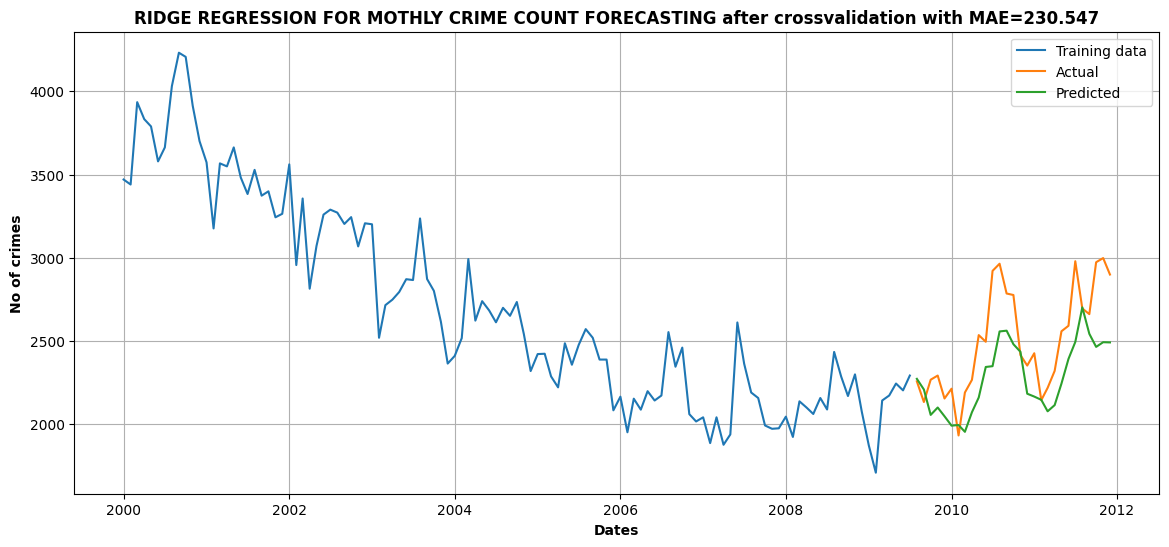

In [ ]:
##ridge chart
plt.figure(figsize=(14,6))
plt.plot(y_train.index,y_train,label='Training data')
plt.plot(y_test.index,y_test,label='Actual')
plt.plot(y_test.index,r_pred,label='Predicted')
plt.xlabel('Dates',weight='bold')
plt.ylabel('No of crimes',weight='bold')
plt.title(f"RIDGE REGRESSION FOR MOTHLY CRIME COUNT FORECASTING after crossvalidation with MAE={mae:.3f}",weight='bold')
plt.legend()
plt.grid()
plt.show()

###### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

**The error score has reduced to ~230 after hyperparameter tuning on ridgregression**

##### Lasso regression

In [ ]:
###code for lasso regression using grid search cv
lasso = Lasso(max_iter=1000)

##parameters
param = {
    'alpha':[0.001,0.01,0.1,1.0,10],
    'fit_intercept':[True,False]
}

l_grid = GridSearchCV(lasso,cv=tsv,param_grid=param,scoring="neg_mean_absolute_error",n_jobs=-1)
l_grid.fit(x_train,y_train)

print("best lasso model: ",l_grid.best_estimator_)
print("best mae score: ",l_grid.best_score_)

best lasso model:  Lasso(alpha=10)
best mae score:  -224.12197964630906


In [ ]:
##predict
best_lasso = l_grid.best_estimator_
lapred = best_lasso.predict(x_test)

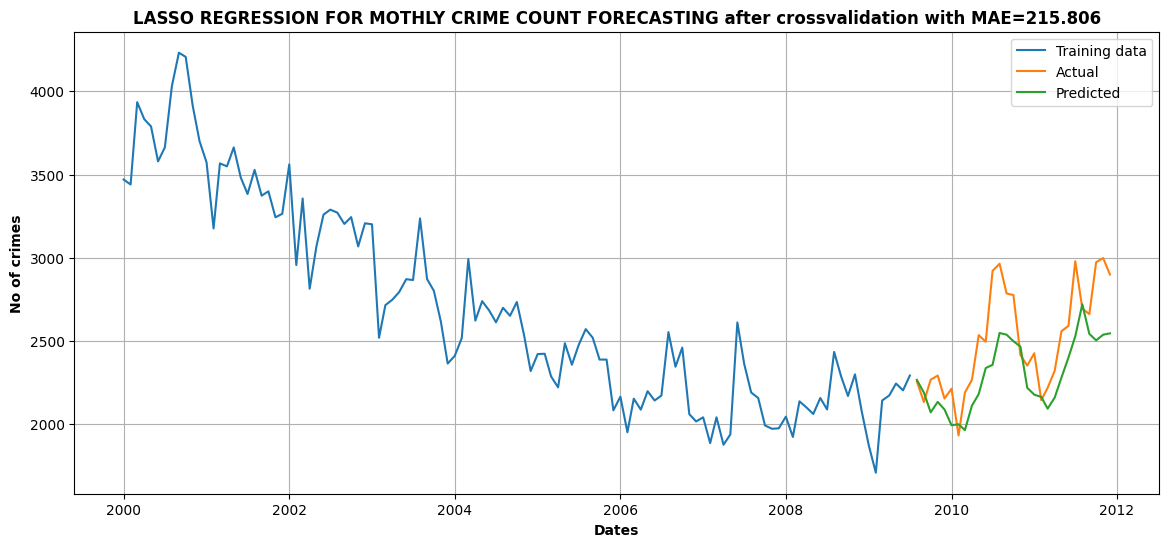

In [ ]:
mae = mean_absolute_error(y_test,lapred)
plt.figure(figsize=(14,6))
plt.plot(y_train.index,y_train,label='Training data')
plt.plot(y_test.index,y_test,label='Actual')
plt.plot(y_test.index,lapred,label='Predicted')
plt.xlabel('Dates',weight='bold')
plt.ylabel('No of crimes',weight='bold')
plt.title(f"LASSO REGRESSION FOR MOTHLY CRIME COUNT FORECASTING after crossvalidation with MAE={mae:.3f}",weight='bold')
plt.legend()
plt.grid()
plt.show()

**The error has reduced to ~215.80 after hyperparameter tuning of lasso regression**

### ML Model -4 RANDOMFOREST REGRESSION

In [ ]:
##simple random forest classifer
from sklearn.ensemble import RandomForestRegressor
rf= RandomForestRegressor(random_state=2501,n_jobs=-1)
rf.fit(x_train,y_train)

##predict
rfg_pred = rf.predict(x_test)
mae = mean_absolute_error(y_test,rfg_pred)
print("mean absolute error for RandomforestRegressor: ",mae)

mean absolute error for RandomforestRegressor:  268.41275862068954


#### CrossValidation and Hyperparameter tuning

In [ ]:
##parameters
param = {
    'n_estimators':[100,150],
    'max_depth':[5,10],
    'min_samples_split':[2,6,8,10],
    'min_samples_leaf':[1,2,4]
}

##gridsearch
rf_grid = GridSearchCV(rf,cv=tsv,param_grid=param,scoring='neg_mean_absolute_error',n_jobs=-1)
rf_grid.fit(x_train,y_train)

##bestmodels
print("best random forest model: ",rf_grid.best_estimator_)
print("best mae score: ",rf_grid.best_score_)
best_rf = rf_grid.best_estimator_

best random forest model:  RandomForestRegressor(max_depth=5, min_samples_split=6, n_jobs=-1,
                      random_state=2501)
best mae score:  -251.031849487544


In [ ]:
##performing prediction
rf_pred = best_rf.predict(x_test)
mae = mean_absolute_error(y_test,rf_pred)
print("mean absolute error of random forest after crossvalidation: ",mae)

mean absolute error of random forest after crossvalidation:  270.0717887319576


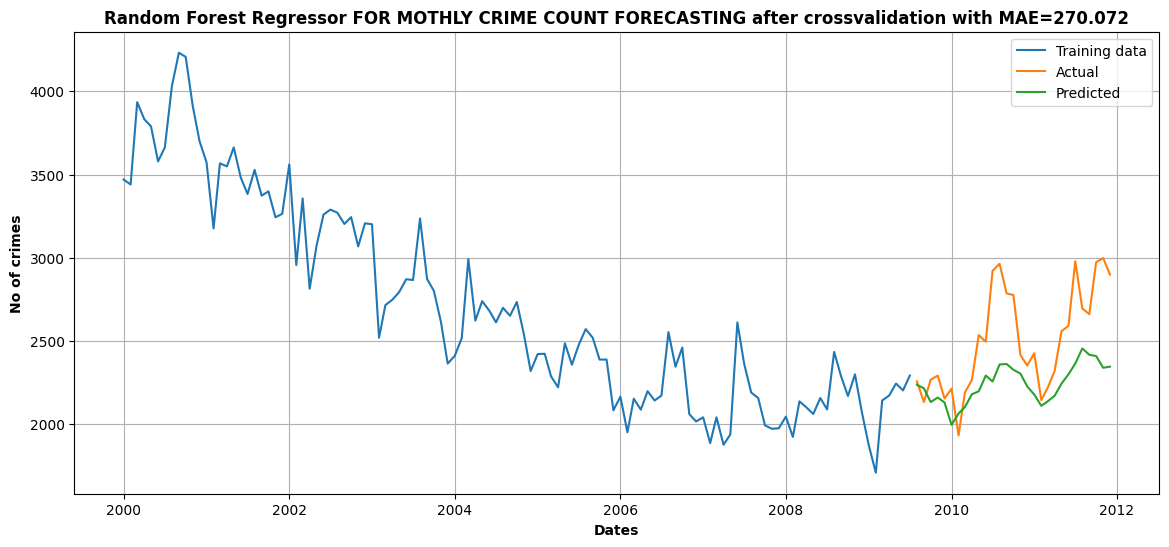

In [ ]:
##chart
plt.figure(figsize=(14,6))
plt.plot(y_train.index,y_train,label='Training data')
plt.plot(y_test.index,y_test,label='Actual')
plt.plot(y_test.index,rf_pred,label='Predicted')
plt.xlabel('Dates',weight='bold')
plt.ylabel('No of crimes',weight='bold')
plt.title(f"Random Forest Regressor FOR MOTHLY CRIME COUNT FORECASTING after crossvalidation with MAE={mae:.3f}",weight='bold')
plt.legend()
plt.grid()
plt.show()

**The error score for RandomForestregressor is ~270.02, which is higher when you compare with other models.**

### ML Model-5 XGBOOST Regressor

In [ ]:
##simple xgbregressor
from xgboost import XGBRegressor
xgb = XGBRegressor(objective='reg:squarederror',n_job=-1,random_state=2501)
xgb.fit(x_train,y_train)

##prediction
xg_pred = xgb.predict(x_test)
mae = mean_absolute_error(y_test,xg_pred)
print("mean absolute error for simple XGBregressor: ",mae)

mean absolute error for simple XGBregressor:  261.92083740234375


#### Cross validation and Hyperparameter Tuning

In [ ]:
##parameters
param = {
    'n_estimators':[100,150],
    'max_depth':[2,5,8],
    'learning_rate':[0.01,0.05,0.1,1.0],
    'min_child_weight':[1,3,5],
    'gamma':[0.1,0.3]
}

##gridsearch
xgb_grid = GridSearchCV(xgb,cv=tsv,param_grid=param,scoring='neg_mean_absolute_error',n_jobs=-1)
xgb_grid.fit(x_train,y_train)

best_xgb = xgb_grid.best_estimator_
print("best xgb regressor: ",best_xgb)
print("best mae score: ",xgb_grid.best_score_)

best xgb regressor:  XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=150,
             n_job=-1, n_jobs=None, ...)
best mae score:  -242.5487091064453


In [ ]:
##training on full data
best_xgb.fit(x_train,y_train)
xgb_pred1 = best_xgb.predict(x_test)
mae = mean_absolute_error(y_test,xgb_pred1)

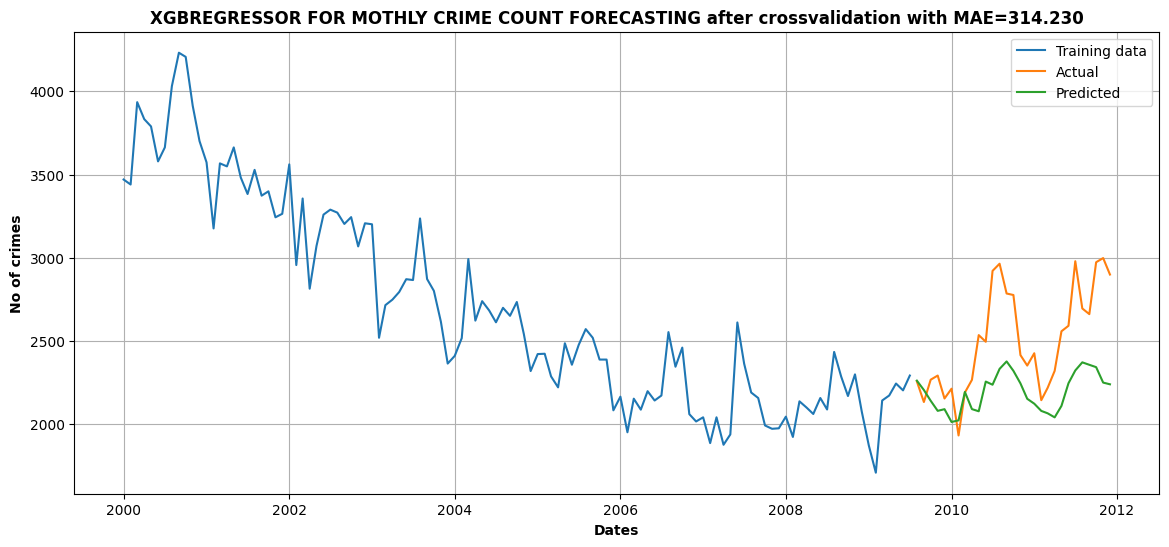

In [ ]:
##chart
plt.figure(figsize=(14,6))
plt.plot(y_train.index,y_train,label='Training data')
plt.plot(y_test.index,y_test,label='Actual')
plt.plot(y_test.index,xgb_pred1,label='Predicted')
plt.xlabel('Dates',weight='bold')
plt.ylabel('No of crimes',weight='bold')
plt.title(f"XGBREGRESSOR FOR MOTHLY CRIME COUNT FORECASTING after crossvalidation with MAE={mae:.3f}",weight='bold')
plt.legend()
plt.grid()
plt.show()

**The mean absolute error (314.23) for XGBREGRESSOR is the largest among all trained models**

## **8. Which ML model did you choose from the above created models as your final prediction model and why?**

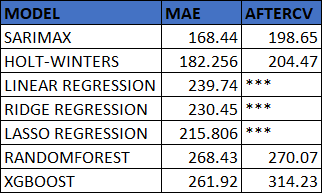

1. **Among all models, SARIMAX is the most promising model, because it has smallest forecasting error ~168.00 (i.e. On average, the forecast differs from the true monthly crime count by about 168 incidents). SARIMAX explicitly models the long-term decline and later increase in crime count (predicted values move in same direction as actual), and also captures the repeating annual pattern (peaks and troughs in both actual and predicted lines). The model closely tracks the decline in crime count in 2011 and rebound during later months.**

2. **Although slightly less accurate (error = ~184), Holt-Winters is also a promising model. It is simpler to implement, easier to train, and requires fewer assumptions.**


## ***9. Stage 2:-  Crime Type,and Neighbourhood Specific Forecasting using SARIMAX***

### 1. Neighbourhood specific crime count forecasting

#### Data preperation

In [ ]:
##setting date as an index
data1.set_index('Date',inplace=True)

In [ ]:
##neighbourhood specific crime count in each month, eveyr year
neigh = data1.groupby('NEIGHBOURHOOD').resample('ME').size().reset_index(name='count')

In [ ]:
neigh.head()

,NEIGHBOURHOOD,Date,count
0,Arbutus Ridge,1999-01-31,75
1,Arbutus Ridge,1999-02-28,47
2,Arbutus Ridge,1999-03-31,60
3,Arbutus Ridge,1999-04-30,62
4,Arbutus Ridge,1999-05-31,43


In [ ]:
##chart to visualise the crime count in each neighbourhood over time

from ipywidgets import interact, Dropdown


# List of neighbourhoods
neighbourhoods = sorted(
    neigh['NEIGHBOURHOOD']
    .dropna()
    .unique()
)

# Plot function
def plot_neighbourhood(neighbourhood):

    temp = neigh[
        neigh['NEIGHBOURHOOD'] == neighbourhood
    ]

    plt.figure(figsize=(14, 5))

    sns.lineplot(
        data=temp,
        x='Date',
        y='count',
        marker='o'
    )

    plt.title(
        f'Monthly Crime Count in {neighbourhood}',
        fontweight='bold'
    )
    plt.xlabel('Date', fontweight='bold')
    plt.ylabel('Crime Count', fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Interactive dropdown
interact(
    plot_neighbourhood,
    neighbourhood=Dropdown(
        options=neighbourhoods,
        description='Neighbourhood: '
    )
)

interactive(children=(Dropdown(description='Neighbourhood: ', options=('Arbutus Ridge', 'Central Business Dist…

<function __main__.plot_neighbourhood(neighbourhood)>

#### SARIMAX TRAINING ON EACH NEIGHBOURHOOD

In [ ]:
##neighbourhood names
neighbourhoods = neigh['NEIGHBOURHOOD'].unique()

In [ ]:
##model training
import joblib
neigh_data = []

for neighbourhood in neighbourhoods:
  n_data = neigh[neigh['NEIGHBOURHOOD']==neighbourhood].set_index('Date')['count'].sort_index()

  ##data spliting
  n= int(len(n_data)*0.9)
  n_train = n_data.iloc[:n]
  n_test = n_data.iloc[n:]

  ##model training
  model = SARIMAX(n_train,order=(2,1,2),seasonal_order=(2,1,2,12))
  n_fit = model.fit(disp=False,)

  ##forecasting on testdata
  pred = n_fit.forecast(steps=len(n_test))

  ##forecasting for next 12 months
  future = n_fit.forecast(steps=12)

  ##saving the forecast data
  neigh_data.append({'Date':n_test.index,
                     "NEIGHBOURHOOD":neighbourhood,
                     "TEST":n_test,
                     "PREDICTED":pred,
                     "MAE":mean_absolute_error(n_test,pred),
                     "NEXT_12":future,
                     "MODEL":n_fit})

  joblib.dump(n_fit,f"/content/stage2{neighbourhood}sarimax.pkl")




In [ ]:
##creating an output dataframe
neighbourhood_data = pd.DataFrame([
    {
        'Date': result['Date'],
        'NEIGHBOURHOOD': result['NEIGHBOURHOOD'],
        'TEST': list(result['TEST'].values),
        'PREDICTED': list(result['PREDICTED'].round(2).values),
        'MAE': result['MAE'],
        'NEXT_12': list(result['NEXT_12'].round(2).values),
        'MODEL': result['MODEL']
    }
    for result in neigh_data
])

# View result
neighbourhood_data.head()

,Date,NEIGHBOURHOOD,TEST,PREDICTED,MAE,NEXT_12,MODEL
0,"DatetimeIndex(['2010-09-30', '2010-10-31', '20...",Arbutus Ridge,"[46, 44, 39, 30, 26, 21, 21, 24, 27, 28, 40, 2...","[28.28, 26.97, 37.16, 36.61, 26.59, 26.36, 26....",8.516255,"[28.28, 26.97, 37.16, 36.61, 26.59, 26.36, 26....",<statsmodels.tsa.statespace.sarimax.SARIMAXRes...
1,"DatetimeIndex(['2010-09-30', '2010-10-31', '20...",Central Business District,"[635, 588, 651, 561, 605, 577, 527, 546, 648, ...","[602.39, 534.49, 544.05, 560.49, 568.88, 587.8...",75.991095,"[602.39, 534.49, 544.05, 560.49, 568.88, 587.8...",<statsmodels.tsa.statespace.sarimax.SARIMAXRes...
2,"DatetimeIndex(['2010-09-30', '2010-10-31', '20...",Dunbar-Southlands,"[29, 40, 32, 40, 45, 30, 32, 47, 39, 40, 63, 4...","[45.79, 45.09, 43.59, 37.9, 38.74, 37.47, 45.6...",9.220560,"[45.79, 45.09, 43.59, 37.9, 38.74, 37.47, 45.6...",<statsmodels.tsa.statespace.sarimax.SARIMAXRes...
3,"DatetimeIndex(['2010-09-30', '2010-10-31', '20...",Fairview,"[215, 174, 143, 118, 147, 126, 155, 135, 165, ...","[176.45, 162.41, 170.74, 157.19, 152.97, 135.9...",19.141330,"[176.45, 162.41, 170.74, 157.19, 152.97, 135.9...",<statsmodels.tsa.statespace.sarimax.SARIMAXRes...
4,"DatetimeIndex(['2010-09-30', '2010-10-31', '20...",Grandview-Woodland,"[121, 163, 126, 148, 134, 129, 130, 124, 141, ...","[133.21, 153.96, 128.11, 121.92, 117.98, 111.2...",13.720125,"[133.21, 153.96, 128.11, 121.92, 117.98, 111.2...",<statsmodels.tsa.statespace.sarimax.SARIMAXRes...


In [ ]:
##data for visualization
lists=[]
for _,row in neighbourhood_data[['Date','NEIGHBOURHOOD','TEST','PREDICTED']].iterrows():
  temp = pd.DataFrame({
      'Date':list(row['Date']),
      'Neighbourhood':[row['NEIGHBOURHOOD']]*len(row['Date']),
      'Test':list(row['TEST']),
      'Predicted':list(row['PREDICTED'])
  })

  lists.append(temp)

##coverting to dataframe
neighbourhood_df = pd.concat(lists,ignore_index=True)

neighbourhood_df['Date'] = pd.to_datetime(neighbourhood_df['Date'])



In [ ]:
neighbourhood_df.head(10)

,Date,Neighbourhood,Test,Predicted
0,2010-09-30,Arbutus Ridge,46,28.28
1,2010-10-31,Arbutus Ridge,44,26.97
2,2010-11-30,Arbutus Ridge,39,37.16
3,2010-12-31,Arbutus Ridge,30,36.61
4,2011-01-31,Arbutus Ridge,26,26.59
5,2011-02-28,Arbutus Ridge,21,26.36
6,2011-03-31,Arbutus Ridge,21,26.55
7,2011-04-30,Arbutus Ridge,24,34.32
8,2011-05-31,Arbutus Ridge,27,29.29
9,2011-06-30,Arbutus Ridge,28,34.67


In [ ]:
##visualization actual vs prediciton

neighbourhoods = neighbourhood_df['Neighbourhood'].unique()

def plot_actvpred(neighbourhood1):
  ts = neighbourhood_df[neighbourhood_df['Neighbourhood']==neighbourhood1]

  plt.figure(figsize=(14,5))
  sns.lineplot(x='Date',y='Test',data=ts,marker='o',lw=2,label='ACTUAL')
  sns.lineplot(x='Date',y='Predicted',data=ts,marker='o',lw=2,label='PREDICTED')
  plt.title(f"{neighbourhood1} crimes over the years for ACTUAL VS PREDICTED",weight='bold')
  plt.xlabel('Years',weight='bold')
  plt.ylabel('No of crimes',weight='bold')
  plt.grid()
  plt.tight_layout()
  plt.show()


interact(
    plot_actvpred,
    neighbourhood1=Dropdown(
        options=neighbourhoods,
        description="Neighbourhoods: "
    )
)

interactive(children=(Dropdown(description='Neighbourhoods: ', options=('Arbutus Ridge', 'Central Business Dis…

<function __main__.plot_actvpred(neighbourhood1)>

### 2.Crime type specific crime count forecasting

#### Data preperation

In [ ]:
ct = data1.groupby('TYPE').resample('ME').size().reset_index(name='count') ##crime type specific data

In [ ]:
ct.head()

,TYPE,Date,count
0,Break and Enter Commercial,1999-01-31,303
1,Break and Enter Commercial,1999-02-28,254
2,Break and Enter Commercial,1999-03-31,292
3,Break and Enter Commercial,1999-04-30,266
4,Break and Enter Commercial,1999-05-31,291


In [ ]:
ct['TYPE'].unique()

array(['Break and Enter Commercial', 'Break and Enter Residential/Other',
       'Mischief', 'Offence Against a Person', 'Other Theft',
       'Theft from Vehicle', 'Theft of Bicycle', 'Theft of Vehicle',
       'Vehicle Collision or Pedestrian Struck (with Injury)'],
      dtype=object)

In [ ]:
###crime count visualization for each crime type over the years
from ipywidgets import interact,Dropdown
types = ct['TYPE'].unique()

def plot_crime(type):
  ts = ct[ct['TYPE']==type]

  plt.figure(figsize=(14,5))
  sns.lineplot(x='Date',y='count',data=ts,marker='o',lw=2)
  plt.title(f"{type} crimes over the years",weight='bold')
  plt.xlabel('Years',weight='bold')
  plt.ylabel('No of crimes',weight='bold')
  plt.grid()
  plt.tight_layout()
  plt.show()


interact(
    plot_crime,
    type=Dropdown(
        options=types,
        description="Crime Types: "
    )
)




interactive(children=(Dropdown(description='Crime Types: ', options=('Break and Enter Commercial', 'Break and …

<function __main__.plot_crime(type)>

#### SARIMAX model training on each crime type

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

type_data=[]

for type in types:
  ts1 = ct[ct['TYPE']==type].set_index('Date')['count'].sort_index()

  ##SPLITTING
  t = int(len(ts1)*0.9)
  t_train = ts1.iloc[:t]
  t_test = ts1.iloc[t:]
  ##training
  model = SARIMAX(t_train,order=(2,1,2),seasonal_order=(2,1,2,12))
  t_fit = model.fit()

  ##prediction
  t_pred = t_fit.forecast(steps=len(t_test))
  ##future 12months
  t_future = t_fit.forecast(steps=12)

  mae = mean_absolute_error(t_test,t_pred)

  type_data.append({
      'DATE':t_test.index,
      'TYPE':type,
      'TEST':t_test,
      'PREDICTED':t_pred,
      'MAE':mae,
      'NEXT_12':t_future,
      'MODEL':t_fit
  })
  joblib.dump(t_fit,f"/content/sample_data/stage2'{type[:25]}'sarimax.pkl")

In [ ]:
crimetype_data = pd.DataFrame([{
    'DATE':result['DATE'],
    'TYPE':result['TYPE'],
    'TEST':list(result['TEST'].values),
    'PREDICTED':list(result['PREDICTED'].round(2).values),
    'MAE':result['MAE'],
    'FUTURE':list(result['NEXT_12'].round(2).values),
    'MODEL':result['MODEL']}

    for result in type_data
    ])

In [ ]:
##display results
crimetype_data.head()

,DATE,TYPE,TEST,PREDICTED,MAE,FUTURE,MODEL
0,"DatetimeIndex(['2010-09-30', '2010-10-31', '20...",Break and Enter Commercial,"[213, 200, 205, 202, 228, 187, 192, 179, 188, ...","[163.58, 171.37, 154.62, 167.03, 170.2, 148.23...",38.789238,"[163.58, 171.37, 154.62, 167.03, 170.2, 148.23...",<statsmodels.tsa.statespace.sarimax.SARIMAXRes...
1,"DatetimeIndex(['2010-09-30', '2010-10-31', '20...",Break and Enter Residential/Other,"[212, 286, 257, 298, 294, 210, 219, 187, 231, ...","[265.15, 282.23, 281.48, 280.0, 267.82, 209.16...",28.353092,"[265.15, 282.23, 281.48, 280.0, 267.82, 209.16...",<statsmodels.tsa.statespace.sarimax.SARIMAXRes...
2,"DatetimeIndex(['2010-09-30', '2010-10-31', '20...",Mischief,"[379, 423, 337, 328, 315, 324, 339, 348, 380, ...","[326.98, 361.88, 300.62, 307.31, 303.6, 291.91...",32.999887,"[326.98, 361.88, 300.62, 307.31, 303.6, 291.91...",<statsmodels.tsa.statespace.sarimax.SARIMAXRes...
3,"DatetimeIndex(['2010-09-30', '2010-10-31', '20...",Offence Against a Person,"[30, 31, 30, 31, 31, 28, 31, 30, 31, 30, 31, 3...","[30.01, 31.0, 30.01, 31.01, 31.01, 28.43, 31.0...",0.042209,"[30.01, 31.0, 30.01, 31.01, 31.01, 28.43, 31.0...",<statsmodels.tsa.statespace.sarimax.SARIMAXRes...
4,"DatetimeIndex(['2010-09-30', '2010-10-31', '20...",Other Theft,"[333, 352, 389, 340, 390, 385, 387, 391, 407, ...","[365.39, 329.85, 335.1, 327.82, 358.75, 348.73...",46.016717,"[365.39, 329.85, 335.1, 327.82, 358.75, 348.73...",<statsmodels.tsa.statespace.sarimax.SARIMAXRes...


In [ ]:
# Build a list of DataFrames, then concatenate them
dfs = []

for _, row in crimetype_data[['DATE', 'TYPE', 'TEST', 'PREDICTED', 'FUTURE']].iterrows():
    temp = pd.DataFrame({
        'Date': list(row['DATE']),
        'Crime_Type': [row['TYPE']] * len(row['DATE']),
        'Test_Count': list(row['TEST']),
        'Predicted': list(row['PREDICTED'])
    })
    dfs.append(temp)

# Concatenate all DataFrames
crimetype_df = pd.concat(dfs, ignore_index=True)

# Convert Date to datetime
crimetype_df['Date'] = pd.to_datetime(crimetype_df['Date'])

In [ ]:
crimetype_df.head(10)

,Date,Crime_Type,Test_Count,Predicted
0,2010-09-30,Break and Enter Commercial,213,163.58
1,2010-10-31,Break and Enter Commercial,200,171.37
2,2010-11-30,Break and Enter Commercial,205,154.62
3,2010-12-31,Break and Enter Commercial,202,167.03
4,2011-01-31,Break and Enter Commercial,228,170.20
5,2011-02-28,Break and Enter Commercial,187,148.23
6,2011-03-31,Break and Enter Commercial,192,174.15
7,2011-04-30,Break and Enter Commercial,179,156.08
8,2011-05-31,Break and Enter Commercial,188,163.10
9,2011-06-30,Break and Enter Commercial,212,187.40


In [ ]:
##visualization actual vs prediciton

types = crimetype_df['Crime_Type'].unique()

def plot_crime(type):
  ts = crimetype_df[crimetype_df['Crime_Type']==type]

  plt.figure(figsize=(14,5))
  sns.lineplot(x='Date',y='Test_Count',data=ts,marker='o',lw=2,label='ACTUAL')
  sns.lineplot(x='Date',y='Predicted',data=ts,marker='o',lw=2,label='PREDICTED')
  plt.title(f"{type} crimes over the years for ACTUAL VS PREDICTED",weight='bold')
  plt.xlabel('Years',weight='bold')
  plt.ylabel('No of crimes',weight='bold')
  plt.grid()
  plt.tight_layout()
  plt.show()


interact(
    plot_crime,
    type=Dropdown(
        options=types,
        description="Crime Types: "
    )
)




interactive(children=(Dropdown(description='Crime Types: ', options=('Break and Enter Commercial', 'Break and …

<function __main__.plot_crime(type)>

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
##saving the models
import joblib
joblib.dump(srm1,'/content/stage1sarimax.pkl')


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***